# Flux calibration: 2019B

In [1]:
import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
os.sys.path.append(magePath)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy import units as u
from scipy.interpolate import interp1d

from magE.functions import air
from magE.spec.natural_spline import *
from magE.spec.spec_classes import *

In [6]:
# Reduced by BN
# _multispec -> with the -2D flag
# _multi -> without the -2D flag

dataPath = '/home/benjamin/Documents/analogs/calib/mage19b/mage19b/'

J0023 = MageMultispec.from_fname(dataPath + 'j0023-0948_multi.fits')
J0136 = MageMultispec.from_fname(dataPath + 'j0136-0037_multi.fits')
# J2212 the only EG, the rest Feige110
J0252 = MageMultispec.from_fname(dataPath + 'j0252+0114_multi.fits') # neg
J0305 = MageMultispec.from_fname(dataPath + 'j0305+0040_multi.fits') # key
J2212 = MageMultispec.from_fname(dataPath + 'j2212+0006_multi.fits') # neg
J2337 = MageMultispec.from_fname(dataPath + 'j2337-0010_multi.fits') # iws

# For Feige Calibration
J0023_feige = MageMultispec.from_fname(dataPath + 'j0023-0948_multi.fits')
J0136_feige = MageMultispec.from_fname(dataPath + 'j0136-0037_multi.fits')

# Read Feige110 and EG21 1D spectral data
# Feige110 and EG21 multispec from CarPy

feige110 = MageMultispec.from_fname(dataPath + 'feige110_multi.fits')
eg21 = MageMultispec.from_fname(dataPath + 'eg21_multi.fits')

In [7]:
refPath = '/home/benjamin/Documents/analogs/calib/mage19b/'

# feige110 spectrum from ESO Standard Stars
# keys: 0 -> wavelength (A), 1 -> flux (ergs/cm/cm/s/A * 10**16), 2 -> flux (mJy)

feige110_ref = pd.read_csv(refPath + 'ffeige110.dat', header=None, 
                           sep='\s+', engine='python')
simple_feige110 = SimpleSpectrum(lda=feige110_ref[0], 
                                 flux=feige110_ref[1]*1e-16)

# eg21 spectrum from ESO Standard Stars
# keys: 0 -> wavelength (A), 1 -> flux (ergs/cm/cm/s/A * 10**16)

eg21_ref = pd.read_csv(refPath +'feg21.dat', header=None, sep='\s+', 
                          engine='python')
simple_eg21 = SimpleSpectrum(lda=eg21_ref[0], flux=eg21_ref[1]*1e-16)

In [4]:
flux_calibrate_multispec(J0023, feige110, simple_feige110)

Flux calibrating order : 6
Flux calibrating order : 7

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 8


/home/nava/Documentos/MagE-analogues/magE/spec/spec_classes.py:182: RuntimeWarning: divide by zero encountered in true_divide
  calibration_factor = reference_flux(ref_lda) / obs_flux
/home/nava/Documentos/MagE-analogues/magE/spec/spec_classes.py:184: RuntimeWarning: invalid value encountered in multiply
  calibrated_flux = multispec_target.flux(order) * calibration_factor



Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 9

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 10

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 11

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 12

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 13

Spectres: new_wavs contains values outside the range in spec

In [6]:
flux_calibrate_multispec(J0136, feige110, simple_feige110)

Flux calibrating order : 6
Flux calibrating order : 7

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 8

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 9


/home/nava/Documentos/MagE-analogues/magE/spec/spec_classes.py:182: RuntimeWarning: divide by zero encountered in true_divide
  calibration_factor = reference_flux(ref_lda) / obs_flux
/home/nava/Documentos/MagE-analogues/magE/spec/spec_classes.py:184: RuntimeWarning: invalid value encountered in multiply
  calibrated_flux = multispec_target.flux(order) * calibration_factor



Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 10

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 11

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 12
Flux calibrating order : 13

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 14

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 15
Flux calibrating order : 16

Spe

In [7]:
%matplotlib
for i in range(6, 21):
    J0136.plot(i)

Using matplotlib backend: Qt5Agg


In [6]:
# AIR = VAC / (1.0 + 2.735182e-4 + 131.4182 / VAC^2 + 2.76249e8 / VAC^4)

def air(vac):
    a = 1.0 + 2.735182e-4
    b = 131.4182 / (vac**2)
    c = 2.76249e8 / (vac**4)
    return vac / (a + b + c)

# Reference Star Spline

In [7]:
x = simple_feige110.lda
y = simple_feige110.flux

mask_feige = (x > air(8852)) + (x > air(7568)) * (x < air(7837)) \
            + (x > air(6810)) * (x < air(6913)) \
            + (x > air(5913)) * (x < air(6485)) \
            + (x > air(5455)) * (x < air(5803)) \
            + (x > air(4910)) * (x < air(5213)) \
            + (x > air(4712)) * (x < air(4791)) \
            + (x > air(4012)) * (x < air(4051)) \
            + (x > air(3919)) * (x < air(3944)) \
            + (x > air(3853)) * (x < air(3858)) \
            + (x > air(3812)) * (x < air(3815)) \
            + (x > air(3784)) * (x < air(3788)) + (x < air(3775))

knots = air(np.array([1164, 1326, 1748, 2500, 3000, 3370,
                  3375, 3521, 3765, 3786, 3813.5, 3855.5, 3925, 4022, 4041,
                  4730, 4750, 4770, 5000, 5150, 5500, 5600, 5700, 5790, 5970,
                  6100, 6200, 6400, 6850, 6900, 7600, 7700, 7800, 9000, 10000,
                  11000, 11090]))

In [8]:
# building spline based model
model_model = get_natural_cubic_spline_model(x=simple_feige110.lda[mask_feige],
                                             y=simple_feige110.flux[mask_feige],
                                            minval=np.min(simple_feige110.lda[mask_feige]),
                                            maxval=np.max(simple_feige110.lda[mask_feige]),
                                            knots=knots)

# getting flux
y_est_custom_model = model_model.predict(simple_feige110.lda)

Text(0.5, 0, '$\\lambda$ [$\\AA$]')

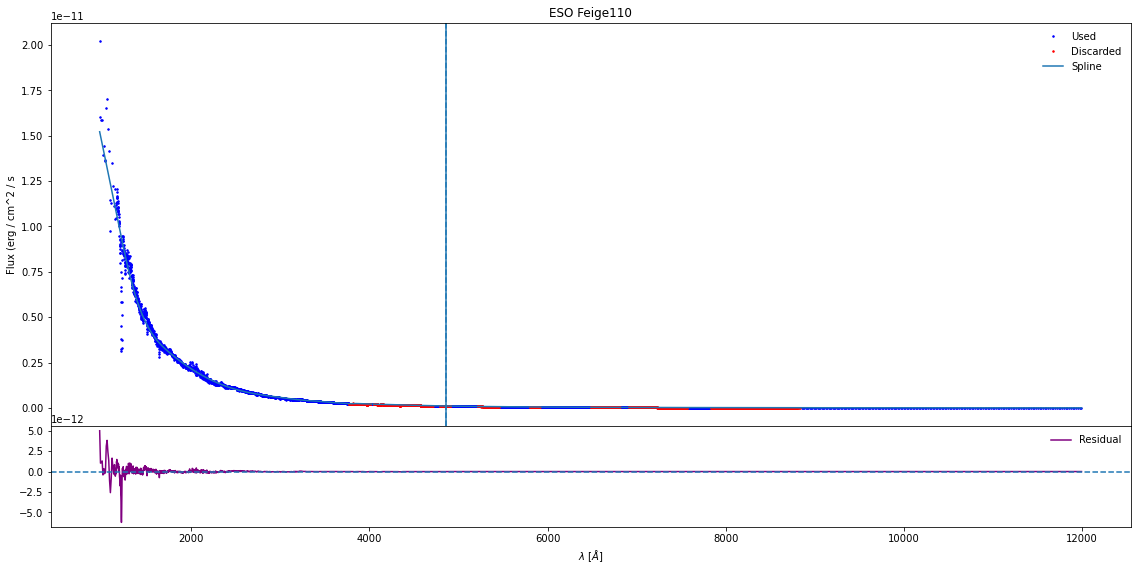

In [9]:
%matplotlib inline

fig = plt.figure(1)
fig.set_size_inches(15, 7)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(simple_feige110.lda[mask_feige], simple_feige110.flux[mask_feige], ls='', marker='.', markersize=3, label='Used', color='blue')
ax.plot(simple_feige110.lda[np.logical_not(mask_feige)], simple_feige110.flux[np.logical_not(mask_feige)], ls='', marker='.', markersize=3, label='Discarded', color='red')
ax.plot(simple_feige110.lda, y_est_custom_model, label='Spline')
ax.legend(frameon=False)
ax.set_ylabel('Flux (erg / cm^2 / s')
ax.set_title('ESO Feige110')

ax.axvline(4861.363, ls='--', label='Air')
ax.axvline(4862.721, label='Vacuum')

ax1.plot(x, y - y_est_custom_model, label='Residual', color='purple')
ax1.legend(frameon=False)
ax1.axhline(0, ls='--')
ax1.set_xlabel(r'$\lambda$ [$\AA$]');

In [10]:
reference_flux = interp1d(simple_feige110.lda,
                              model_model.predict(simple_feige110.lda),
                              kind='linear', bounds_error=False,
                              fill_value=np.nan, assume_sorted=True)

# Observed star spline

# Order 6

In [11]:
x6 = feige110.wavelength(6)
y6 = feige110.flux(6)

mask6 = (x6 > 9504.07) * (x6 < 9515.8) + (x6 > 9648.6) * (x6 < 9651.8) \
      + (x6 > 9813)

knots6 = np.array([9510, 9650, 9850, 9900, 10050, 10400, 11000])

In [12]:
model_custom6 = get_natural_cubic_spline_model(x=x6[mask6],
                                               y=y6[mask6], 
                                               minval=np.min(x6),
                                               maxval=np.max(x6),
                                               knots=knots6)
y_est_custom6 = model_custom6.predict(feige110.wavelength(6))

In [13]:
obs_flux6 = spectres(simple_feige110.lda, feige110.wavelength(6), 
                     y_est_custom6, verbose=False)
factor6 = reference_flux(simple_feige110.lda)/obs_flux6

Text(0.5, 0, '$\\lambda$ [$\\AA$]')

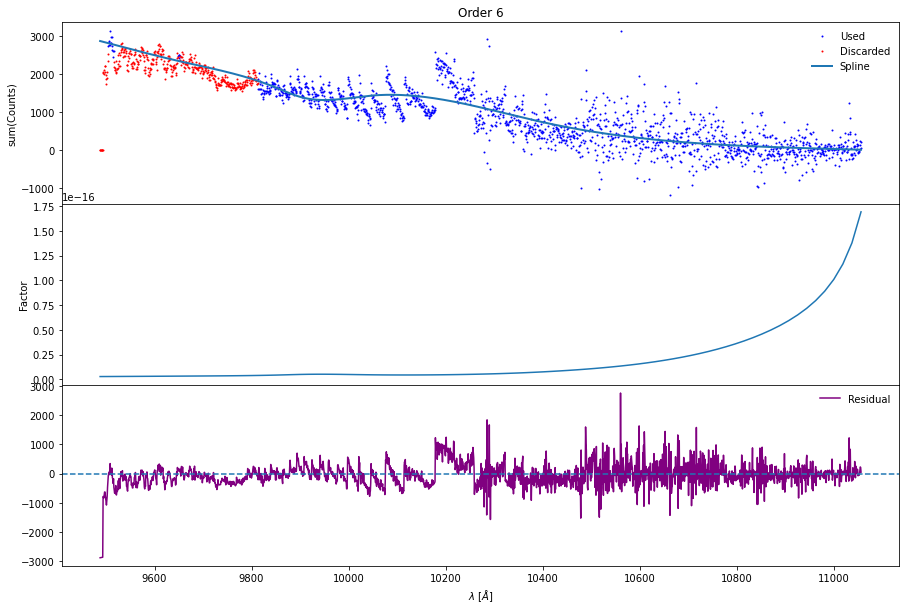

In [14]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(x6[mask6], y6[mask6], ls='', marker='.',
            markersize=2, label='Used', color='blue')
axs[0].plot(x6[np.logical_not(mask6)], y6[np.logical_not(mask6)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(feige110.wavelength(6), y_est_custom6, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 6')

axs[1].plot(simple_feige110.lda, factor6)
axs[1].set_ylabel('Factor')

axs[2].plot(feige110.wavelength(6), feige110.flux(6) - y_est_custom6,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]')

# Order 7

In [15]:
y7 = feige110.flux(7)
x7 = feige110.wavelength(7)

mask7 = (x7 > 8170) * (x7 < 8174) + (x7 > 8202) * (x7 < 8207) \
        + (x7 > 8403) * (x7 < 8421) + (x7 > 8475) * (x7 < 8496) \
        + (x7 > 8602) * (x7 < 8619) + (x7 > 8667) * (x7 < 8673) \
        + (x7 > 8808) * (x7 < 8813) + (x7 > 8888) * (x7 < 8895) \
        + (x7 > 8906) * (x7 < 8916) + (x7 > 9046) * (x7 < 9055) \
        + (x7 > 9160) * (x7 < 9165) + (x7 > 9255) * (x7 < 9272) \
        + (x7 > 9447) * (x7 < 9452)

knots7 = np.array([8172, 8205, 8410, 8485, 8610, 8669, 8810, 8890,
                   8910, 9050, 9163, 9265, 9450])

In [16]:
model_custom7 = get_natural_cubic_spline_model(x=x7[mask7],
                                               y=y7[mask7],
                                               minval=np.min(x7),
                                               maxval=np.max(x7),
                                               knots=knots7)
y_est_custom7 = model_custom7.predict(feige110.wavelength(7))

In [17]:
obs_flux7 = spectres(simple_feige110.lda, feige110.wavelength(7),
                     y_est_custom7, verbose=False)
factor7 = reference_flux(simple_feige110.lda)/obs_flux7

Text(0.5, 0, '$\\lambda$ [$\\AA$]')

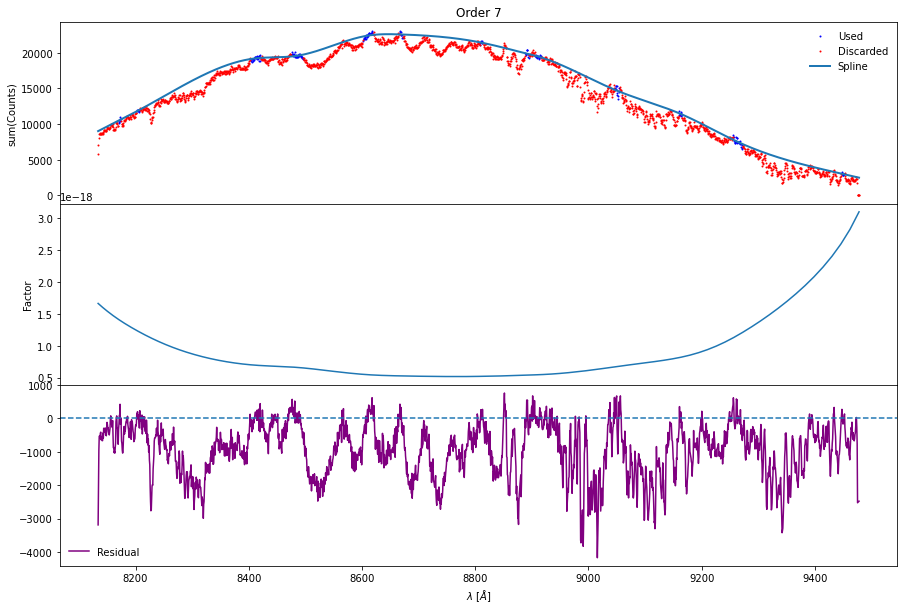

In [18]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(x7[mask7], y7[mask7], ls='', marker='.',
            markersize=2, label='Used', color='blue')
axs[0].plot(x7[np.logical_not(mask7)], y7[np.logical_not(mask7)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(feige110.wavelength(7), y_est_custom7, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 7')

axs[1].plot(simple_feige110.lda, factor7)
axs[1].set_ylabel('Factor')

axs[2].plot(feige110.wavelength(7), feige110.flux(7) - y_est_custom7,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]')

# Order 8

In [19]:
y8_1 = feige110.flux(8)[5:827]
x8_1 = feige110.wavelength(8)[5:827]

y8_int = feige110.flux(8)[827:1014]
x8_int = feige110.wavelength(8)[827:1014]

y8_2 = feige110.flux(8)[1014:]
x8_2 = feige110.wavelength(8)[1014:]

mask8_1 = (x8_1 > 7130) * (x8_1 < 7162) + (x8_1 > 7209) * (x8_1 < 7224) \
        + (x8_1 > 7400) * (x8_1 < 7407) + (x8_1 > 7485) * (x8_1 < 7490) \
        + (x8_1 > 7515) * (x8_1 < 7519) + (x8_1 > 7573) * (x8_1 < 7583)

mask8_2 = (x8_2 > 7733) * (x8_2 < 7740) + (x8_2 > 7765) * (x8_2 < 7770)\
        + (x8_2 > 7964) * (x8_2 < 7975) \
        + (x8_2 > 8204) * (x8_2 < 8219) + (x8_2 > 8245) * (x8_2 < 8275)

x8 = feige110.flux(8)
mask8 = (x8 > 7130) * (x8 < 7162) + (x8 > 7209) * (x8 < 7224) \
        + (x8 > 7400) * (x8 < 7407) + (x8 > 7485) * (x8 < 7490) \
        + (x8 > 7515) * (x8 < 7519) + (x8 > 7573) * (x8 < 7583) \
        + (x8 > 7733) * (x8 < 7740) + (x8 > 7765) * (x8 < 7770)\
        + (x8 > 7964) * (x8 < 7975) \
        + (x8 > 8204) * (x8 < 8219) + (x8 > 8245) * (x8 < 8275)

knots8_1 = np.array([7145, 7223, 7404, 7487, 7515, 7579])
knots8_2 = np.array([7737, 7768, 7970, 8210, 8260])

In [20]:
model_custom8_1 = get_natural_cubic_spline_model(x=x8_1[mask8_1],
                                                 y=y8_1[mask8_1],
                                                 minval=np.min(x8_1),
                                                 maxval=np.max(x8_1),
                                                 knots=knots8_1)
y_est_custom8_1 = model_custom8_1.predict(feige110.wavelength(8)[:827])

interp_y8 = interp1d(x8_int, y8_int, kind='linear', bounds_error=False,
                     fill_value=np.nan, assume_sorted=True)
y_est_custom8_int = interp_y8(x8_int)

model_custom8_2 = get_natural_cubic_spline_model(x=x8_2[mask8_2],
                                                 y=y8_2[mask8_2],
                                                 minval=np.min(x8_2),
                                                 maxval=np.max(x8_2),
                                                 knots=knots8_2)
y_est_custom8_2 = model_custom8_2.predict(x8_2)

y_est_custom8 = np.concatenate((y_est_custom8_1, y_est_custom8_int,
                                y_est_custom8_2))

In [21]:
obs_flux8 = spectres(simple_feige110.lda, feige110.wavelength(8),
                     y_est_custom8, verbose=False)
factor8 = reference_flux(simple_feige110.lda)/obs_flux8

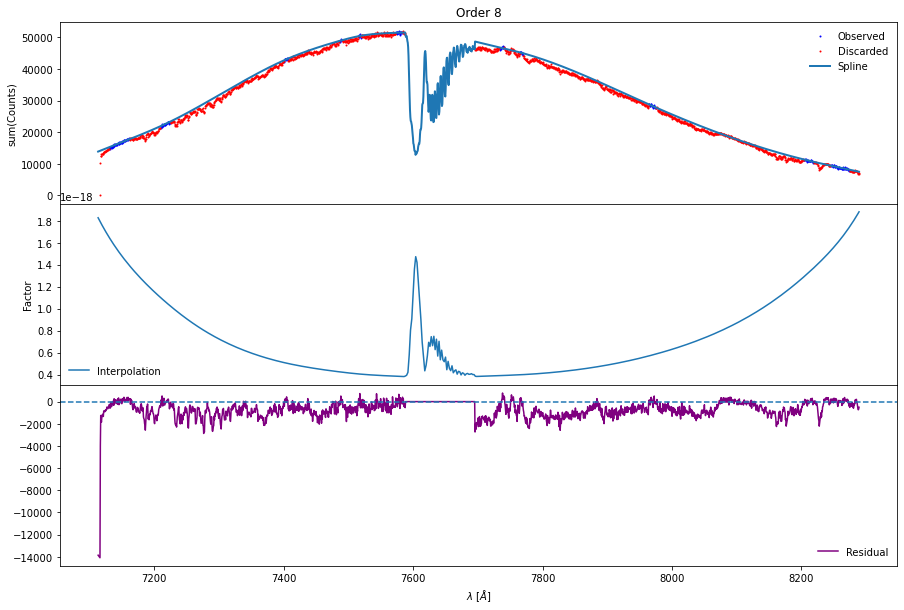

In [22]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(x8_1[mask8_1], y8_1[mask8_1],
            ls='', marker='.', markersize=2, label='Observed', color='blue')
axs[0].plot(x8_2[mask8_2], y8_2[mask8_2],
            ls='', marker='.', markersize=2, color='blue')
axs[0].plot(x8_1[np.logical_not(mask8_1)], y8_1[np.logical_not(mask8_1)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(x8_2[np.logical_not(mask8_2)], y8_2[np.logical_not(mask8_2)],
            ls='', marker='.', markersize=2, color='red')
axs[0].plot(feige110.wavelength(8), y_est_custom8, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 8')

axs[1].plot(simple_feige110.lda, factor8, label='Interpolation')
#axs[1].plot(wl8_sm, factor8_sm, label='Smoothed')
axs[1].set_ylabel('Factor')
axs[1].legend(frameon=False)

axs[2].plot(feige110.wavelength(8), feige110.flux(8) - y_est_custom8,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

# Order 9

In [23]:
y9_1 = feige110.flux(9)[:1056]
x9_1 = feige110.wavelength(9)[:1056]

y9_int = feige110.flux(9)[1056:1268]
x9_int = feige110.wavelength(9)[1056:1268]

y9_2 = feige110.flux(9)[1268:]
x9_2 = feige110.wavelength(9)[1268:]

mask9_1 = (x9_1 > 6329) * (x9_1 < 6506) + (x9_1 > 6595) * (x9_1 < 6704) \
        + (x9_1 > 6790) * (x9_1 < 6858)
mask9_2 = (x9_2 > 6970) * (x9_2 < 6984) + (x9_2 > 7031) * (x9_2 < 7061) \
        + (x9_2 > 7112) * (x9_2 < 7143) + (x9_2 > 7321) * (x9_2 < 7360)

x9 = feige110.flux(9)
mask9 = (x9 > 6329) * (x9 < 6506) + (x9 > 6595) * (x9 < 6860) \
      + (x9 > 6970) * (x9 < 6984) + (x9 > 7031) * (x9 < 7061) \
      + (x9 > 7112) * (x9 < 7143) + (x9 > 7321) * (x9 < 7360)

knots9_1 = np.array([6338, 6370, 6390, 6420, 6470, 6600, 6700, 6800, 6850])
knots9_2 = np.array([6978, 7045, 7100, 7130, 7350, 7359])

In [24]:
model_custom9_1 = get_natural_cubic_spline_model(x=x9_1[mask9_1],
                                                 y=y9_1[mask9_1],
                                                 minval=np.min(x9_1),
                                                 maxval=np.max(x9_1),
                                                 knots=knots9_1)
y_est_custom9_1 = model_custom9_1.predict(feige110.wavelength(9)[:1056])

interp_y9 = interp1d(x9_int, y9_int, kind='linear', bounds_error=False,
                     fill_value=np.nan, assume_sorted=True)
y_est_custom9_int = interp_y9(x9_int)

model_custom9_2 = get_natural_cubic_spline_model(x=x9_2[mask9_2],
                                                 y=y9_2[mask9_2],
                                                 minval=np.min(x9_2),
                                                 maxval=np.max(x9_2),
                                                 knots=knots9_2)
y_est_custom9_2 = model_custom9_2.predict(x9_2)

y_est_custom9 = np.concatenate((y_est_custom9_1, y_est_custom9_int,
                                y_est_custom9_2))

In [25]:
obs_flux9 = spectres(simple_feige110.lda, feige110.wavelength(9),
                     y_est_custom9, verbose=False)
factor9 = reference_flux(simple_feige110.lda)/obs_flux9

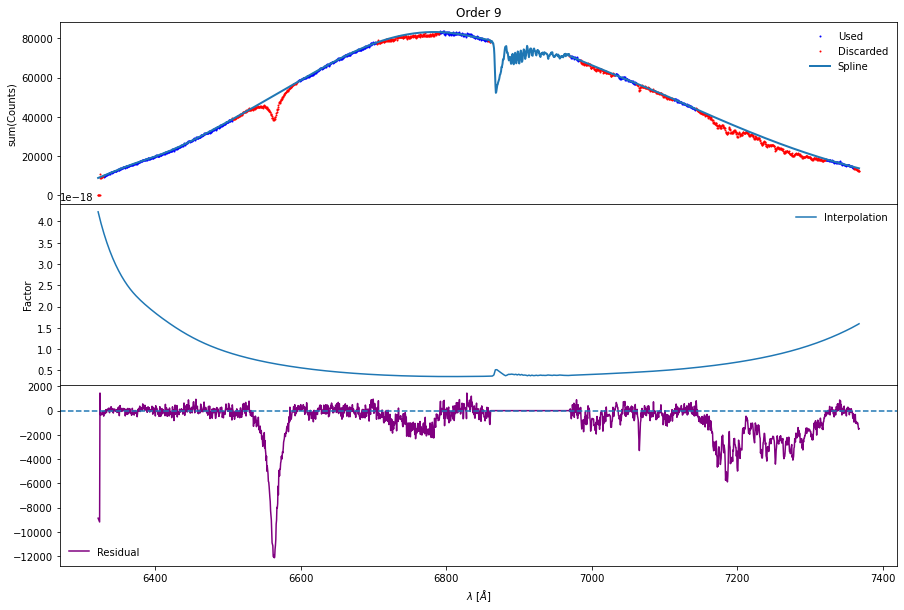

In [26]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(x9_1[mask9_1], y9_1[mask9_1],
            ls='', marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(x9_2[mask9_2], y9_2[mask9_2],
            ls='', marker='.', markersize=2, color='blue')
axs[0].plot(x9_1[np.logical_not(mask9_1)], y9_1[np.logical_not(mask9_1)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(x9_2[np.logical_not(mask9_2)], y9_2[np.logical_not(mask9_2)],
            ls='', marker='.', markersize=2, color='red')
axs[0].plot(feige110.wavelength(9), y_est_custom9, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 9')

axs[1].plot(simple_feige110.lda, factor9, label='Interpolation')
axs[1].set_ylabel('Factor')
axs[1].legend(frameon=False)

axs[2].plot(feige110.wavelength(9), feige110.flux(9) - y_est_custom9,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

# Order 10

In [27]:
y10 = feige110.flux(10)
x10 = feige110.wavelength(10)

mask10 = (x10 > 5691) * (x10 < 5783) + (x10 > 5851) * (x10 < 5865) \
       + (x10 > 5903) * (x10 < 5912) + (x10 > 5965) * (x10 < 5974) \
       + (x10 > 6026) * (x10 < 6033) + (x10 > 6123) * (x10 < 6131) \
       + (x10 > 6263) * (x10 < 6272) + (x10 > 6400) * (x10 < 6415) \
       + (x10 > 6492) * (x10 < 6506) + (x10 > 6580) * (x10 < 6616)

knots10 = np.array([5697, 5750, 5760, 5780, 5858, 5908, 5970, 6029, 6127,
                    6268, 6408, 6499, 6585, 6600])

In [28]:
model_custom10 = get_natural_cubic_spline_model(x=x10[mask10],
                                                y=y10[mask10],
                                                minval=np.min(x10),
                                                maxval=np.max(x10),
                                                knots=knots10)
y_est_custom10 = model_custom10.predict(feige110.wavelength(10))

In [29]:
obs_flux10 = spectres(simple_feige110.lda, feige110.wavelength(10),
                      y_est_custom10, verbose=False)
factor10 = reference_flux(simple_feige110.lda)/obs_flux10

Text(0.5, 0, '$\\lambda$ [$\\AA$]')

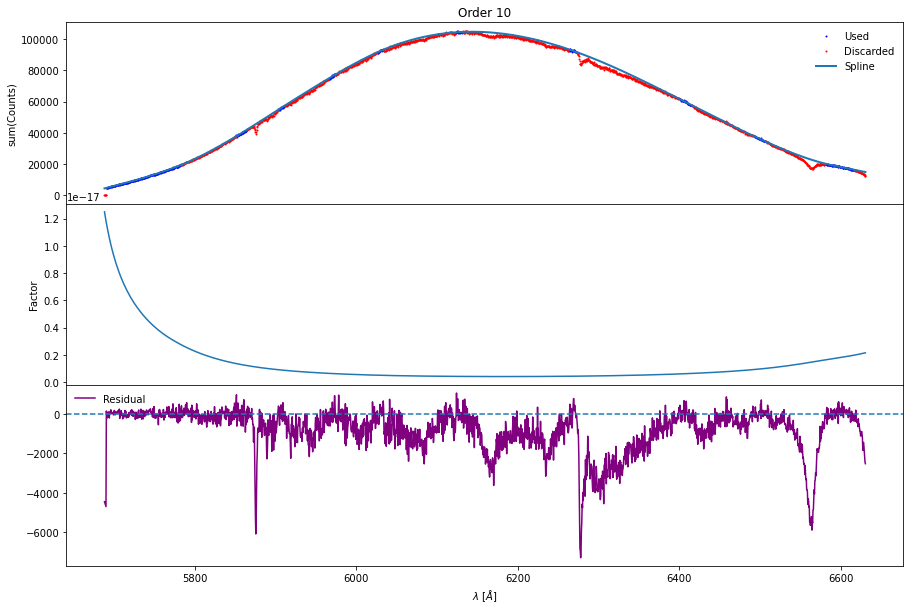

In [30]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(x10[mask10], y10[mask10],
            ls='', marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(x10[np.logical_not(mask10)], y10[np.logical_not(mask10)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(feige110.wavelength(10), y_est_custom10, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 10')

axs[1].plot(simple_feige110.lda, factor10)
axs[1].set_ylabel('Factor')

axs[2].plot(feige110.wavelength(10), feige110.flux(10) - y_est_custom10,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

# Order 11

In [31]:
x11 = feige110.wavelength(11)
y11 = feige110.flux(11)

mask11 = (x11 > 5174) * (x11 < 5398) + (x11 > 5428) * (x11 < 5477) \
       + (x11 > 5528) * (x11 < 5530) + (x11 > 5557) * (x11 < 5561) \
       + (x11 > 5578) * (x11 < 5583) + (x11 > 5640) * (x11 < 5642) \
       + (x11 > 5695) * (x11 < 5700) + (x11 > 5722) * (x11 < 5726) \
       + (x11 > 5819) * (x11 < 5871) + (x11 > 5904)

knots11 = np.array([5183, 5233, 5295, 5335, 5385, 5450, 5529, 5559,
                    5580, 5641, 5698, 5724, 5845, 5908,
                    5940, 5978, 6021])

In [32]:
model_custom11 = get_natural_cubic_spline_model(x=x11[mask11],
                                                y=y11[mask11],
                                                minval=np.min(x11),
                                                maxval=np.max(x11),
                                                knots=knots11)
y_est_custom11 = model_custom11.predict(feige110.wavelength(11))

In [33]:
obs_flux11 = spectres(simple_feige110.lda, feige110.wavelength(11),
                      y_est_custom11, verbose=False)
factor11 = reference_flux(simple_feige110.lda)/obs_flux11

Text(0.5, 0, '$\\lambda$ [$\\AA$]')

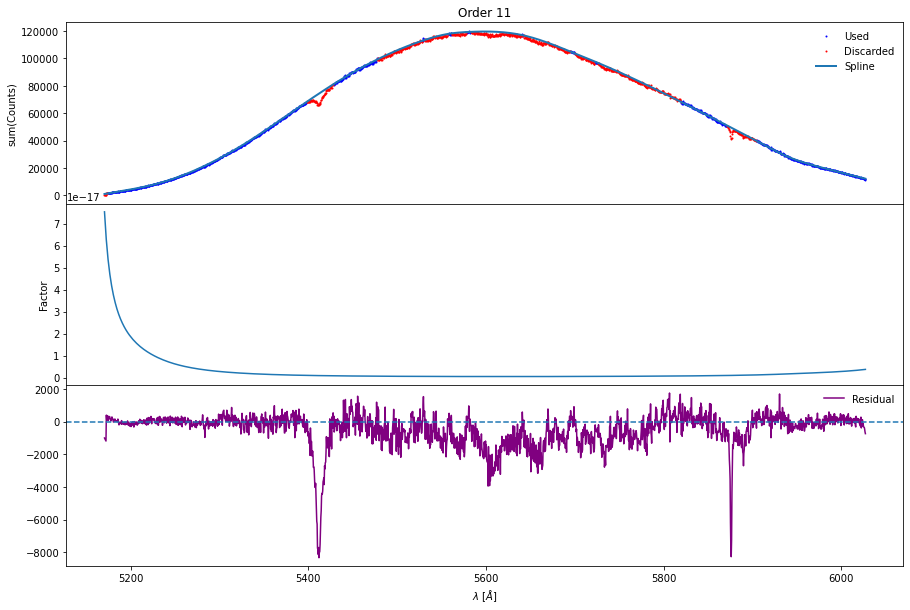

In [34]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(x11[mask11], y11[mask11],
            ls='', marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(x11[np.logical_not(mask11)], y11[np.logical_not(mask11)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(feige110.wavelength(11), y_est_custom11, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 11')

axs[1].plot(simple_feige110.lda, factor11)
axs[1].set_ylabel('Factor')

axs[2].plot(feige110.wavelength(11), feige110.flux(11) - y_est_custom11,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

# Order 12

In [35]:
y12 = feige110.flux(12)
x12 = feige110.wavelength(12)

mask12 = (x12 > 4740) * (x12 < 4841) + (x12 > 4877) * (x12 < 5014) \
       + (x12 > 5075) * (x12 < 5079) \
       + (x12 > 5129) * (x12 < 5134) \
       + (x12 > 5164) * (x12 < 5179) \
       + (x12 > 5265) * (x12 < 5268) + (x12 > 5399) * (x12 < 5402) \
       + (x12 > 5420)

knots12 = np.array([4742, 4754, 4780, 4830, 4916, 5003, 5077,
                    5132, 5170, 5267, 5400,
                    5440, 5470, 5520])

In [36]:
model_custom12 = get_natural_cubic_spline_model(x=x12[mask12],
                                                y=y12[mask12],
                                                minval=np.min(x12),
                                                maxval=np.max(x12),
                                                knots=knots12)
y_est_custom12 = model_custom12.predict(feige110.wavelength(12))

In [37]:
obs_flux12 = spectres(simple_feige110.lda, feige110.wavelength(12),
                      y_est_custom12, verbose=False)
factor12 = reference_flux(simple_feige110.lda)/obs_flux12

Text(0.5, 0, '$\\lambda$ [$\\AA$]')

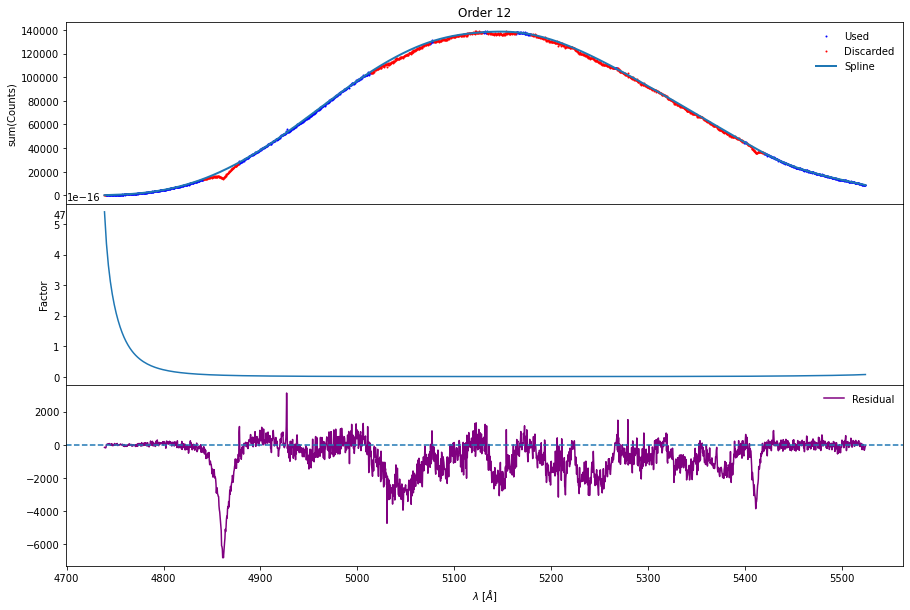

In [38]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(x12[mask12], y12[mask12],
            ls='', marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(x12[np.logical_not(mask12)], y12[np.logical_not(mask12)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(feige110.wavelength(12), y_est_custom12, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 12')

axs[1].plot(simple_feige110.lda, factor12)
axs[1].set_ylabel('Factor')

axs[2].plot(feige110.wavelength(12), feige110.flux(12) - y_est_custom12,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]')

# Order 13

In [39]:
y13 = feige110.flux(13)
x13 = feige110.wavelength(13)

mask13 = (x13 > 4376) * (x13 < 4468) + (x13 > 4475) * (x13 < 4524) \
       + (x13 > 4559) * (x13 < 4604) + (x13 > 4654) * (x13 < 4668) \
       + (x13 > 4727) * (x13 < 4732) + (x13 > 4781) * (x13 < 4786) \
       + (x13 > 4893)

knots13 = np.array([4379, 4429, 4486, 4520, 4580, 4530, 4730, 4783,
                    4961, 5016, 5051, 5091])

In [40]:
model_custom13 = get_natural_cubic_spline_model(x=x13[mask13],
                                                y=y13[mask13],
                                                minval=np.min(x13),
                                                maxval=np.max(x13),
                                                knots=knots13)
y_est_custom13 = model_custom13.predict(feige110.wavelength(13))

In [41]:
obs_flux13 = spectres(simple_feige110.lda, feige110.wavelength(13),
                      y_est_custom13, verbose=False)
factor13 = reference_flux(simple_feige110.lda)/obs_flux13

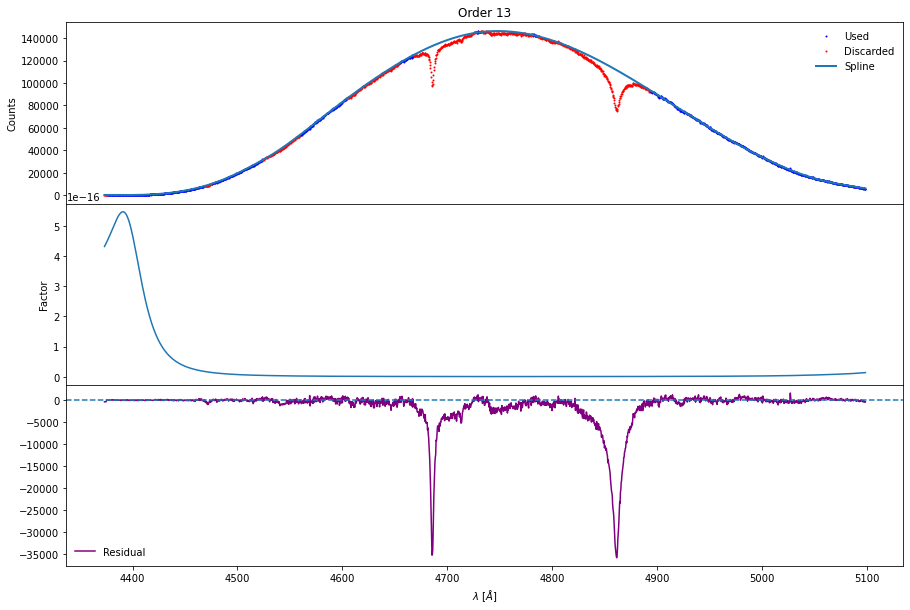

In [42]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(x13[mask13], y13[mask13],
            ls='', marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(x13[np.logical_not(mask13)], y13[np.logical_not(mask13)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(feige110.wavelength(13), y_est_custom13, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 13')

axs[1].plot(simple_feige110.lda, factor13)
axs[1].set_ylabel('Factor')

axs[2].plot(feige110.wavelength(13), feige110.flux(13) - y_est_custom13,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

# Order 14

In [43]:
y14 = feige110.flux(14)
x14 = feige110.wavelength(14)

mask14 = (x14 > 4062) * (x14 < 4300) + (x14 > 4367) * (x14 < 4377) \
       + (x14 > 4404) * (x14 < 4407) + (x14 > 4415) * (x14 < 4421) \
       + (x14 > 4463) * (x14 < 4466) + (x14 > 4488) * (x14 < 4502) \
       + (x14 > 4517) * (x14 < 4532) + (x14 > 4553) * (x14 < 4678) \
       + (x14 > 4692)

knots14 = np.array([4068, 4127, 4142, 4224, 4289, 4372, 4405, 4418,
                    4465, 4495, 4524, 4614, 4646, 4701, 4729])

In [44]:
model_custom14 = get_natural_cubic_spline_model(x=x14[mask14],
                                                y=y14[mask14],
                                                minval=np.min(x14),
                                                maxval=np.max(x14),
                                                knots=knots14)
y_est_custom14 = model_custom14.predict(feige110.wavelength(14))

In [45]:
obs_flux14 = spectres(simple_feige110.lda, feige110.wavelength(14),
                      y_est_custom14, verbose=False)
factor14 = reference_flux(simple_feige110.lda)/obs_flux14

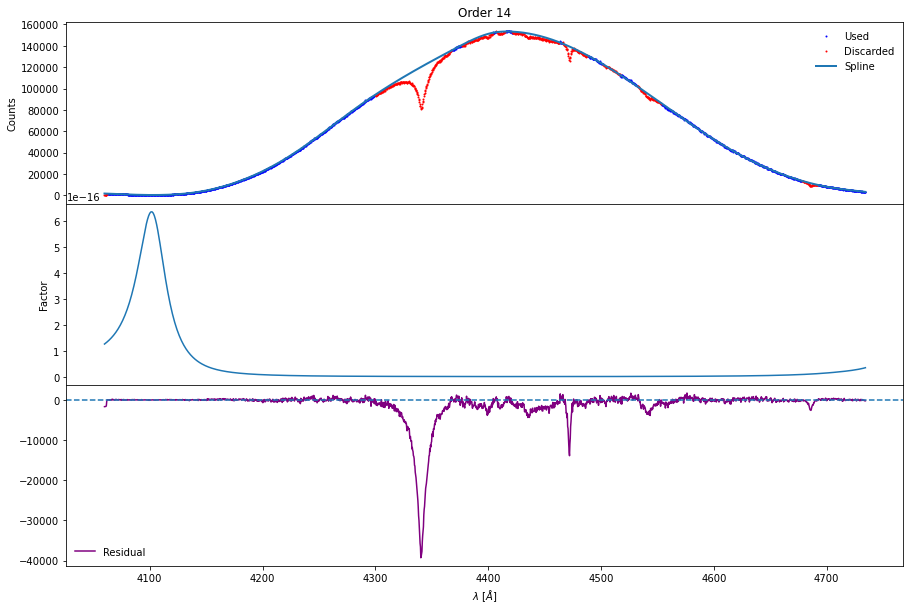

In [46]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(x14[mask14], y14[mask14],
            ls='', marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(x14[np.logical_not(mask14)], y14[np.logical_not(mask14)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(feige110.wavelength(14), y_est_custom14, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 14')

axs[1].plot(simple_feige110.lda, factor14)
axs[1].set_ylabel('Factor')

axs[2].plot(feige110.wavelength(14), feige110.flux(14) - y_est_custom14,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

# Order 15

In [47]:
y15 = feige110.flux(15)
x15 = feige110.wavelength(15)

mask15 = (x15 > 3790) * (x15 < 3932) + (x15 > 3935) * (x15 < 3951) \
       + (x15 > 3989) * (x15 < 4020) + (x15 > 4046) * (x15 < 4053) \
       + (x15 > 4061) * (x15 < 4068) + (x15 > 4073) * (x15 < 4076) \
       + (x15 > 4126) * (x15 < 4128) + (x15 > 4135) * (x15 < 4137) \
       + (x15 > 4157) * (x15 < 4161) + (x15 > 4180) * (x15 < 4187) \
       + (x15 > 4209) * (x15 < 4319) + (x15 > 4357)

knots15 = np.array([3797, 3840, 3876, 3891, 3925, 3946, 4007, 4049,
                    4065, 4074, 4127, 4136, 4159, 4183, 4242, 4303,
                    4367, 4402])

In [48]:
model_custom15 = get_natural_cubic_spline_model(x=x15[mask15],
                                                y=y15[mask15],
                                                minval=np.min(x15),
                                                maxval=np.max(x15),
                                                knots=knots15)
y_est_custom15 = model_custom15.predict(feige110.wavelength(15))

In [49]:
obs_flux15 = spectres(simple_feige110.lda, feige110.wavelength(15),
                      y_est_custom15, verbose=False)
factor15 = reference_flux(simple_feige110.lda)/obs_flux15

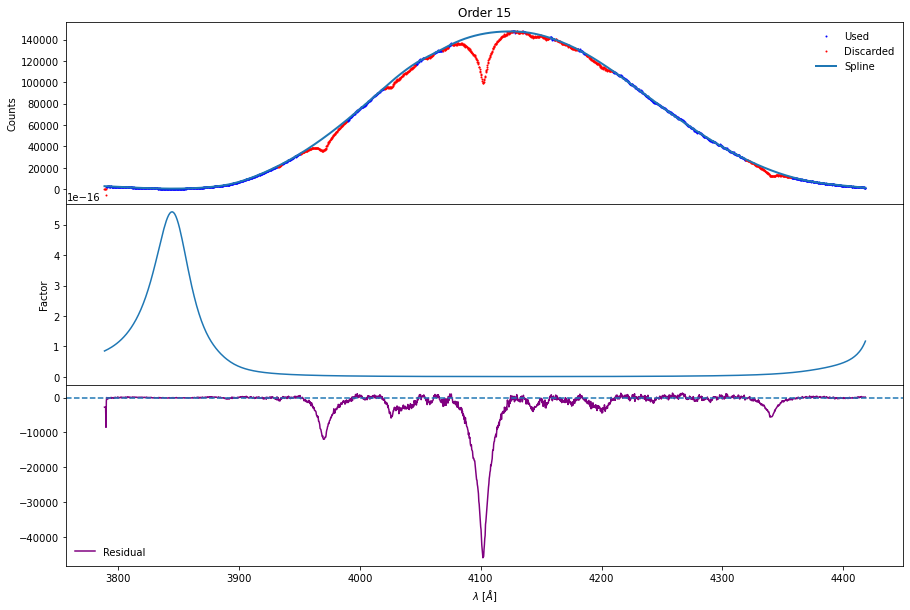

In [50]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(x15[mask15], y15[mask15],
            ls='', marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(x15[np.logical_not(mask15)], y15[np.logical_not(mask15)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(feige110.wavelength(15), y_est_custom15, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 15')

axs[1].plot(simple_feige110.lda, factor15)
axs[1].set_ylabel('Factor')

axs[2].plot(feige110.wavelength(15), feige110.flux(15) - y_est_custom15,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

# Order 16

In [51]:
y16 = feige110.flux(16)
x16 = feige110.wavelength(16)

mask16 = (x16 > 3552) * (x16 < 3706) + (x16 > 3766) * (x16 < 3768) \
       + (x16 > 3810) * (x16 < 3816) + (x16 > 3861) * (x16 < 3865) \
       + (x16 > 3912) * (x16 < 3931) + (x16 > 3938) * (x16 < 3942) \
       + (x16 > 4016) * (x16 < 4020) + (x16 > 4031) * (x16 < 4089) \
       + (x16 > 4110)

knots16 = np.array([3554, 3561, 3618, 3677, 3767, 3813, 3863, 3915,
                    3929, 3940, 4006, 4040, 4075, 4120, 4138])

In [52]:
model_custom16 = get_natural_cubic_spline_model(x=x16[mask16],
                                                y=y16[mask16],
                                                minval=np.min(x16),
                                                maxval=np.max(x16),
                                                knots=knots16)
y_est_custom16 = model_custom16.predict(feige110.wavelength(16))

In [53]:
obs_flux16 = spectres(simple_feige110.lda, feige110.wavelength(16),
                      y_est_custom16, verbose=False)
factor16 = reference_flux(simple_feige110.lda)/obs_flux16

Text(0.5, 0, '$\\lambda$ [$\\AA$]')

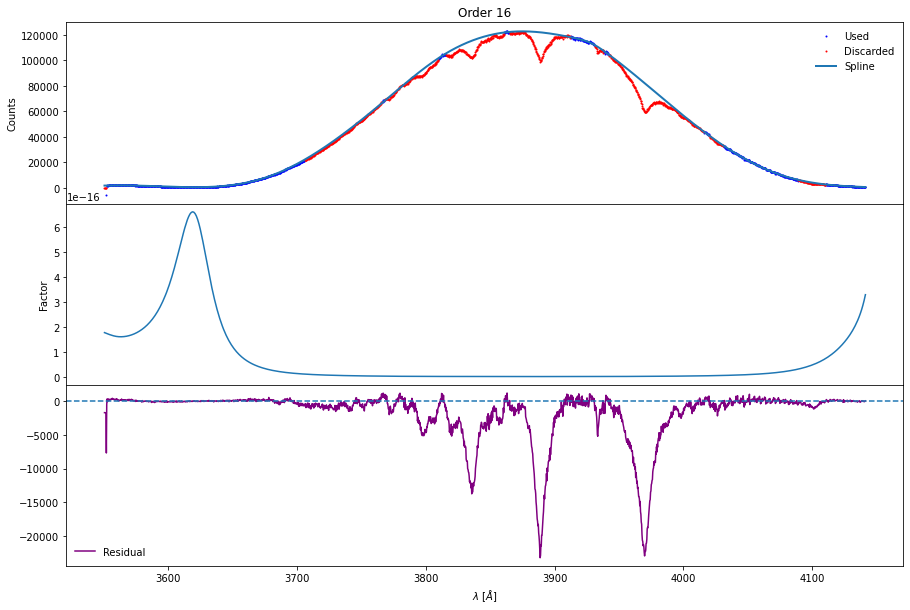

In [54]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(x16[mask16], y16[mask16],
            ls='', marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(x16[np.logical_not(mask16)], y16[np.logical_not(mask16)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(feige110.wavelength(16), y_est_custom16, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 16')

axs[1].plot(simple_feige110.lda, factor16)
axs[1].set_ylabel('Factor')

axs[2].plot(feige110.wavelength(16), feige110.flux(16) - y_est_custom16,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

# Order 17

In [55]:
x17 = feige110.wavelength(17)
y17 = feige110.flux(17)

mask17 = (x17 > 3342) * (x17 < 3483) + (x17 > 3535) * (x17 < 3548) \
       + (x17 > 3555) * (x17 < 3561) + (x17 > 3607) * (x17 < 3610) \
       + (x17 > 3649) * (x17 < 3653) + (x17 > 3663) * (x17 < 3666) \
       + (x17 > 3684) * (x17 < 3690) + (x17 > 3709) * (x17 < 3711) \
       + (x17 > 3759) * (x17 < 3765) + (x17 > 3777) * (x17 < 3784) \
       + (x17 > 3808) * (x17 < 3814) + (x17 > 3846)

knots17 = np.array([3346, 3368, 3392, 3419, 3461, 3541, 3558, 3609,
                    3651, 3665, 3687, 3710, 3762, 3780, 3811, 3856,
                    3892])

In [56]:
model_custom17 = get_natural_cubic_spline_model(x=x17[mask17],
                                                y=y17[mask17],
                                                minval=np.min(x17),
                                                maxval=np.max(x17),
                                                knots=knots17)
y_est_custom17 = model_custom17.predict(feige110.wavelength(17))

In [57]:
obs_flux17 = spectres(simple_feige110.lda, feige110.wavelength(17),
                      y_est_custom17, verbose=False)
factor17 = reference_flux(simple_feige110.lda)/obs_flux17

Text(0.5, 0, '$\\lambda$ [$\\AA$]')

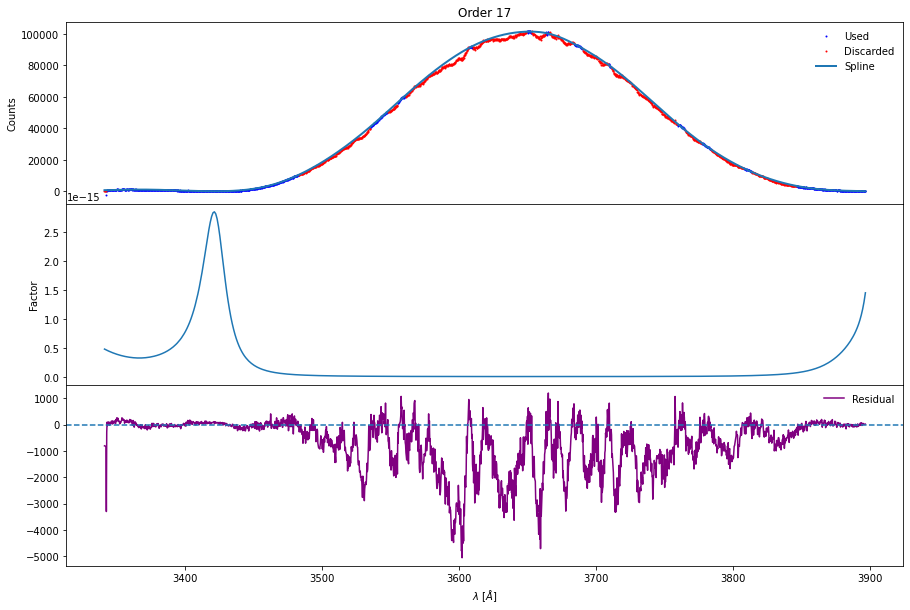

In [58]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(x17[mask17], y17[mask17],
            ls='', marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(x17[np.logical_not(mask17)], y17[np.logical_not(mask17)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(feige110.wavelength(17), y_est_custom17, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 17')

axs[1].plot(simple_feige110.lda, factor17)
axs[1].set_ylabel('Factor')

axs[2].plot(feige110.wavelength(17), feige110.flux(17) - y_est_custom17,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

# Order 18

In [59]:
x18 = feige110.wavelength(18)
y18 = feige110.flux(18)

mask18 = (x18 > 3157) * (x18 < 3191) + (x18 > 3210) * (x18 < 3225) \
       + (x18 > 3260) * (x18 < 3266) + (x18 > 3292) * (x18 < 3299) \
       + (x18 > 3324) * (x18 < 3326) \
       + (x18 > 3351) * (x18 < 3357) + (x18 > 3384) * (x18 < 3387) + (x18 > 3419) * (x18 < 3423) \
       + (x18 > 3431) * (x18 < 3434) + (x18 > 3450) * (x18 < 3454) \
       + (x18 > 3475) * (x18 < 3480) + (x18 > 3490) * (x18 < 3493) \
       + (x18 > 3503.4) * (x18 < 3505.5) + (x18 > 3512.5) * (x18 < 3514.3) \
       + (x18 > 3543) * (x18 < 3546) + (x18 > 3557) * (x18 < 3679.5)

knots18 = np.array([3159, 3170, 3182, 3231, 3263, 3295, 3325, 3354, 3386, 3421,
                    3432, 3452, 3477.5, 3491.5, 3504.5, 3513.5, 3545,
                    3575, 3616, 3651, 3675])

In [60]:
model_custom18 = get_natural_cubic_spline_model(x=x18[mask18],
                                                y=y18[mask18],
                                                minval=np.min(x18),
                                                maxval=np.max(x18),
                                                knots=knots18)
y_est_custom18 = model_custom18.predict(feige110.wavelength(18))

In [61]:
obs_flux18 = spectres(simple_feige110.lda, feige110.wavelength(18),
                      y_est_custom18, verbose=False)
factor18 = reference_flux(simple_feige110.lda)/obs_flux18

Text(0.5, 0, '$\\lambda$ [$\\AA$]')

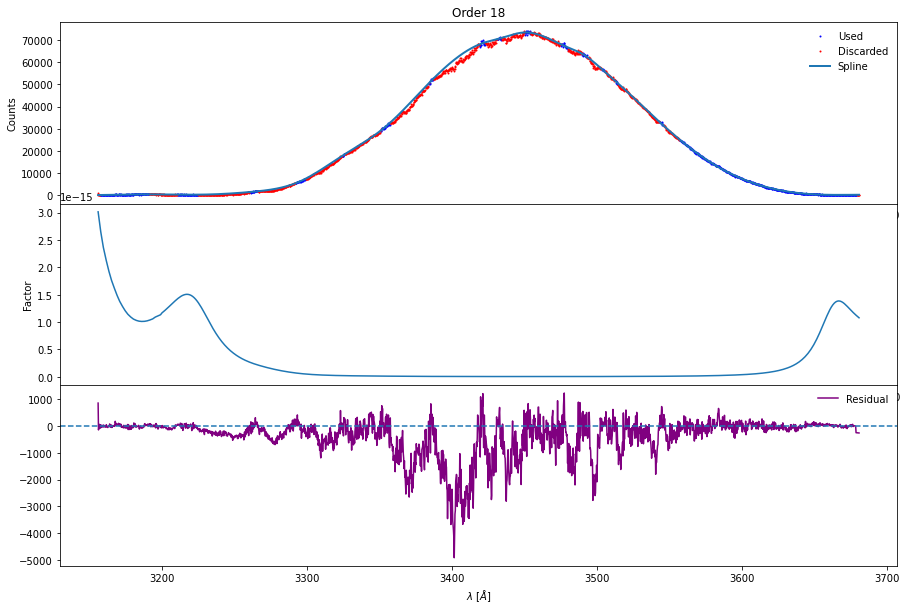

In [62]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(x18[mask18], y18[mask18],
            ls='', marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(x18[np.logical_not(mask18)], y18[np.logical_not(mask18)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(feige110.wavelength(18), y_est_custom18, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 18')

axs[1].plot(simple_feige110.lda, factor18)
axs[1].set_ylabel('Factor')

axs[2].plot(feige110.wavelength(18), feige110.flux(18) - y_est_custom18,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]')

# Order 19

In [63]:
y19 = feige110.flux(19)
x19 = feige110.wavelength(19)

mask19 = (x19 > 3063) * (x19 < 3118) + (x19 > 3142) * (x19 < 3151) \
       + (x19 > 3182) * (x19 < 3193) + (x19 > 3208) * (x19 < 3212) \
       + (x19 > 3236) * (x19 < 3239) + (x19 > 3266) * (x19 < 3268) \
       + (x19 > 3288) * (x19 < 3293) + (x19 > 3322) * (x19 < 3324) \
       + (x19 > 3356) * (x19 < 3362) + (x19 > 3378) * (x19 < 3476)

knots19 = np.array([3068, 3103, 3145, 3187.5, 3210, 3237.5, 3267,
                    3291, 3323, 3359, 3380, 3418, 3446, 3468])

In [64]:
model_custom19 = get_natural_cubic_spline_model(x=x19[mask19],
                                                y=y19[mask19],
                                                minval=np.min(x19),
                                                maxval=np.max(x19),
                                                knots=knots19)
y_est_custom19 = model_custom19.predict(feige110.wavelength(19))

In [65]:
obs_flux19 = spectres(simple_feige110.lda, feige110.wavelength(19),
                      y_est_custom19, verbose=False)
factor19 = reference_flux(simple_feige110.lda)/obs_flux19

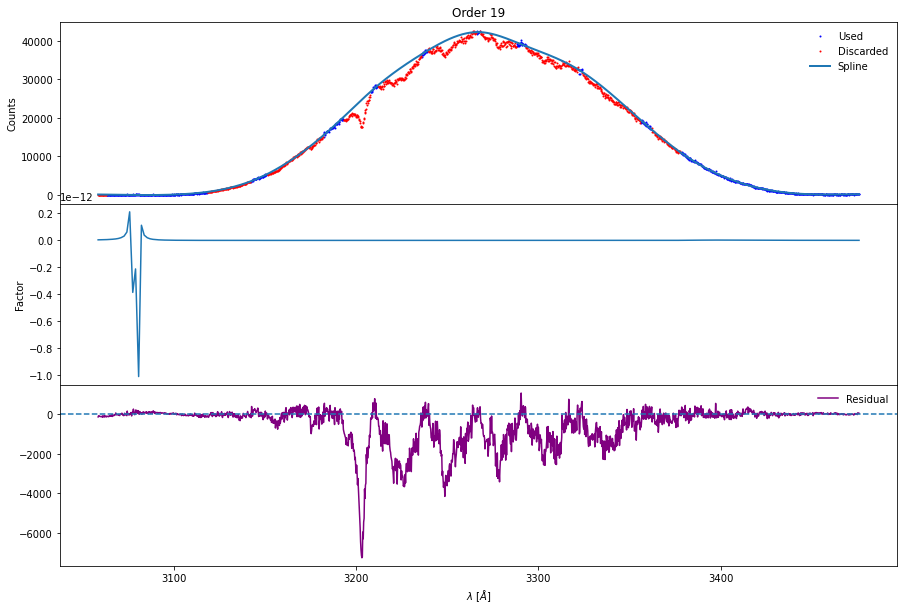

In [66]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(x19[mask19][x19[mask19] < 3476], y19[mask19][x19[mask19] < 3476],
            ls='', marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(x19[np.logical_not(mask19)][x19[np.logical_not(mask19)] < 3476],
            y19[np.logical_not(mask19)][x19[np.logical_not(mask19)] < 3476],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(feige110.wavelength(19)[:1726], y_est_custom19[:1726],
            lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 19')

axs[1].plot(simple_feige110.lda, factor19)
axs[1].set_ylabel('Factor')

axs[2].plot(feige110.wavelength(19)[:1726],
            feige110.flux(19)[:1726] - y_est_custom19[:1726],
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

# Order 20

In [67]:
y20 = feige110.flux(20)
x20 = feige110.wavelength(20)

mask20 = (x20 > 3042.7) * (x20 < 3047.8) + (x20 > 3052.7) * (x20 < 3056.4) \
       + (x20 > 3070.4) * (x20 < 3081.9) + (x20 > 3122) * (x20 < 3126) \
       + (x20 > 3143.3) * (x20 < 3147.4) + (x20 > 3163.29) * (x20 < 3168) \
       + (x20 > 3184.8) * (x20 < 3193.5) + (x20 > 3212) * (x20 < 3218.4) \
       + (x20 > 3233.4) * (x20 < 3296)

knots20 = np.array([3045, 3054, 3075, 3124, 3145.3, 3167, 3189, 3215, 3240,
                    3266, 3290])

In [68]:
model_custom20 = get_natural_cubic_spline_model(x=x20[mask20],
                                                y=y20[mask20],
                                                minval=np.min(x20),
                                                maxval=np.max(x20),
                                                knots=knots20)
y_est_custom20 = model_custom20.predict(feige110.wavelength(20))

In [69]:
obs_flux20 = spectres(simple_feige110.lda, feige110.wavelength(20),
                      y_est_custom20, verbose=False)
factor20 = reference_flux(simple_feige110.lda)/obs_flux20

Text(0.5, 0, '$\\lambda$ [$\\AA$]')

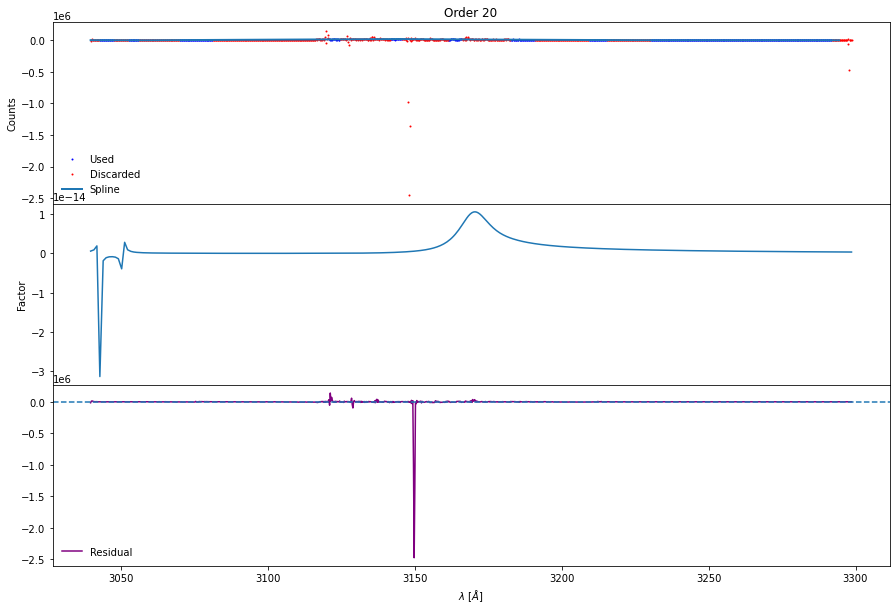

In [70]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(x20[mask20][x20[mask20] < 3303], y20[mask20][x20[mask20] < 3303],
            ls='', marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(x20[np.logical_not(mask20)][x20[np.logical_not(mask20)] < 3303],
            y20[np.logical_not(mask20)][x20[np.logical_not(mask20)] < 3303],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(feige110.wavelength(20)[:1144], y_est_custom20[:1144], lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 20')

axs[1].plot(simple_feige110.lda, factor20)
axs[1].set_ylabel('Factor')

axs[2].plot(feige110.wavelength(20)[:1144],
            feige110.flux(20)[:1144] - y_est_custom20[:1144],
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

# Flux Calibration

In [71]:
simple_feige110.flux[:] = y_est_custom_model

In [72]:
spline_flux = [
    y_est_custom6,
    y_est_custom7,
    y_est_custom8,
    y_est_custom9,
    y_est_custom10,
    y_est_custom11,
    y_est_custom12,
    y_est_custom13,
    y_est_custom14,
    y_est_custom15,
    y_est_custom16,
    y_est_custom17,
    y_est_custom18,
    y_est_custom19,
    y_est_custom20
]

In [73]:
for i in range(6, 21):
    feige110.flux(i)[:] =  spline_flux[i - 6]
    print('Order {:} succesful'.format(i))

Order 6 succesful
Order 7 succesful
Order 8 succesful
Order 9 succesful
Order 10 succesful
Order 11 succesful
Order 12 succesful
Order 13 succesful
Order 14 succesful
Order 15 succesful
Order 16 succesful
Order 17 succesful
Order 18 succesful
Order 19 succesful
Order 20 succesful


In [74]:
flux_calibrate_multispec(J0023, feige110, simple_feige110)
flux_calibrate_multispec(J0136, feige110, simple_feige110)

Flux calibrating order : 6
Flux calibrating order : 7

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 8

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 9

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 10

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 11

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 12

Spectre

In [75]:
%matplotlib

order = 18
plt.errorbar(J0136.wavelength(order), J0136.flux(order), 
             J0136.noise(order), label='with spline')

plt.ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)')
plt.xlabel(r'$\lambda$ [$\AA$]')
plt.legend();

Using matplotlib backend: Qt5Agg


In [76]:
# J0023: Looking good, non-flat continuum in some orders
# J0136: The same features than J0023 with the continuum

# Test Line Ratios

In [77]:
flux_calibrate_multispec(J0023_feige, feige110, simple_feige110)
flux_calibrate_multispec(J0136_feige, feige110, simple_feige110)

Flux calibrating order : 6
Flux calibrating order : 7

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 8

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 9

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 10

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 11

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 12

Spectre

In [79]:
sdssPath = '/home/nava/Documentos/MagE-analogues/SDSS/'

galSpecLine = fits.open(sdssPath + 'galSpecLine-dr8.fits')
galSpecInfo = fits.open(sdssPath + 'galSpecInfo-dr8.fits')
galSpecExtra = fits.open(sdssPath + 'galSpecExtra-dr8.fits')
specObj_dr14 = fits.open(sdssPath + 'specObj-dr14.fits')

galSpecLine_data = galSpecLine[1].data
galSpecInfo_data = galSpecInfo[1].data
galSpecExtra_data = galSpecExtra[1].data

specObjID_J0023 = '735339668748396544'
specObjID_J0136 = '1691125637219117056'

mask_J0023 = galSpecLine_data['SPECOBJID'] == specObjID_J0023
mask_J0136 = galSpecLine_data['SPECOBJID'] == specObjID_J0136

# J0023

In [81]:
import corner
from lmfit import minimize, Parameters
from magE.spec.spec_classes import MageMultispec

class SpecPiece(object):
    
    def __init__(self, name, wavelength, flux, noise):
        self.name = name
        self.wavelength = wavelength
        self.flux = flux
        self.noise = noise

def gaussian(x, A, mu, z, sigma):
    amplitude = A / np.sqrt(2 * np.pi) / sigma
    exp = np.exp(-(x - mu * (1 + z))**2 / 2 / sigma**2 )
    return amplitude * exp

In [112]:
# [NII]6548 + Ha + [NII]6584
select = (J0023_feige.wavelength(9) > 6800) * (J0023_feige.wavelength(9) < 7000)
ha_nii0023feige = SpecPiece('ha+nii', J0023_feige.wavelength(9)[select], 
                   J0023_feige.flux(9)[select], J0023_feige.noise(9)[select])

# Hb + [OIII]4959 + [OIII]5007
select = (J0023_feige.wavelength(12) > 5050) * (J0023_feige.wavelength(12) < 5350)
oiii_hb0023feige = SpecPiece('oiii+hb', J0023_feige.wavelength(12)[select], 
                    J0023_feige.flux(12)[select], J0023_feige.noise(12)[select])

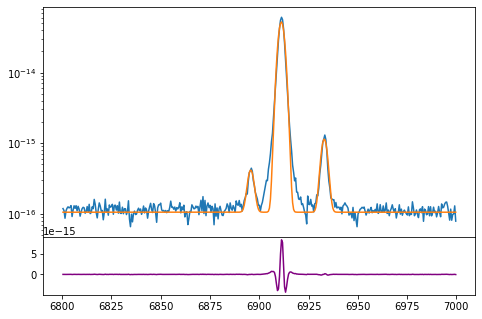

In [100]:
# Search for good initial guess
%matplotlib inline
fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(ha_nii0023feige.wavelength, ha_nii0023feige.flux)

ha_wav = 6564.614
niib_wav = 6549.86
niia_wav = 6585.27
bkg = 1.054839e-16

ha = gaussian(ha_nii0023feige.wavelength, 19.557298e-14, ha_wav, z=0.0528, sigma=1.5)
niib = gaussian(ha_nii0023feige.wavelength, 19.557298e-14 * 0.006, niib_wav, z=0.0528, sigma=1.5)
niia = gaussian(ha_nii0023feige.wavelength, 19.557298e-14 * 0.02, niia_wav, z=0.0528, sigma=1.5)

ax.plot(ha_nii0023feige.wavelength, bkg + niib + ha + niia)
ax1.plot(ha_nii0023feige.wavelength, ha_nii0023feige.flux - bkg - niib - ha - niia, color='purple')
ax.set_yscale('log')

In [105]:
params_ha_nii0023feige = Parameters()

params_ha_nii0023feige.add('z', value=0.0528)
params_ha_nii0023feige.add('sigma', value=1.5, min=0.)
params_ha_nii0023feige.add('Ha_flux', value=19.557298e-14, min=0.)
params_ha_nii0023feige.add('Niib_to_Ha', value=0.006, min=0., max=1.)
params_ha_nii0023feige.add('Niia_to_Ha', value=0.02, min=0., max=1.)
params_ha_nii0023feige.add('bkg', value=1.054839e-16, min=0.)


def residual_ha_nii0023feige(params_ha_nii0023feige, x, data, uncertainty):
    ha_wav = 6564.614
    niib_wav = 6549.86
    niia_wav = 6585.27
    
    z = params_ha_nii0023feige['z']
    sigma = params_ha_nii0023feige['sigma']
    ha_flux = params_ha_nii0023feige['Ha_flux']
    niia_flux = ha_flux * params_ha_nii0023feige['Niia_to_Ha']
    niib_flux = ha_flux * params_ha_nii0023feige['Niib_to_Ha']
    bkg = params_ha_nii0023feige['bkg']
    
    x = ha_nii0023feige.wavelength
    model = gaussian(x, niib_flux, niib_wav, z, sigma) + gaussian(x, ha_flux, ha_wav, z, sigma) + gaussian(x, niia_flux, niia_wav, z, sigma)
    
    return (model + bkg - ha_nii0023feige.flux) / ha_nii0023feige.noise

In [106]:
out_ha_nii0023feige = minimize(residual_ha_nii0023feige, params_ha_nii0023feige, args=(1, 1, 1),
                      method='emcee', burn=1000, steps=2500, thin=10)

100%|███████████████████████████████████████| 2500/2500 [00:44<00:00, 56.44it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 5 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 32.19244554  85.8067916   80.58731372 131.43841704 111.51636313
 118.18889286]


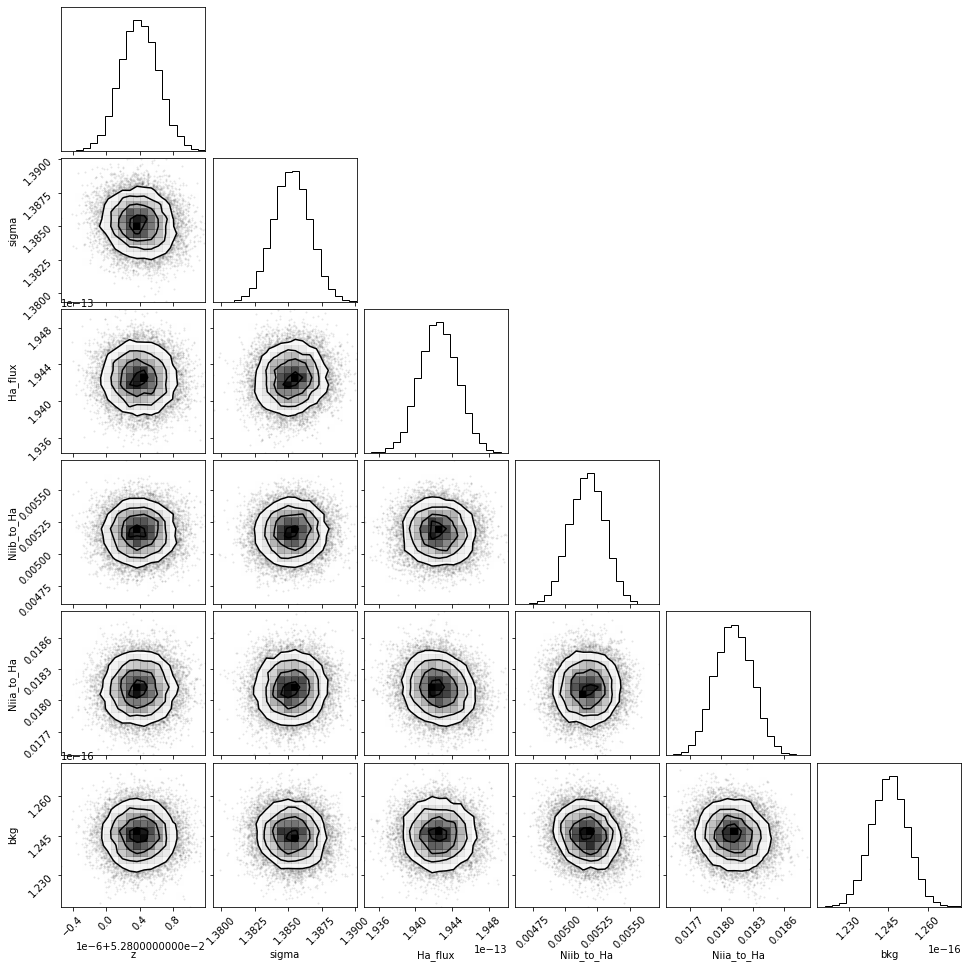

In [107]:
corner.corner(out_ha_nii0023feige.flatchain, labels=out_ha_nii0023feige.var_names);

In [108]:
out_ha_nii0023feige

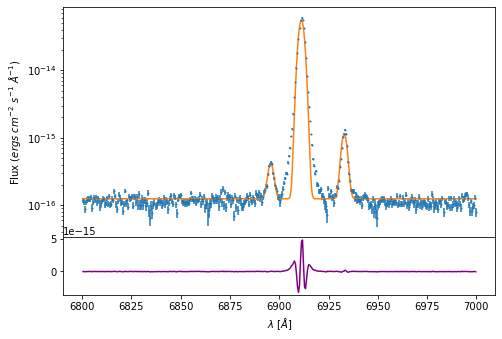

In [109]:
ha_flux0023feige = out_ha_nii0023feige.flatchain.Ha_flux.mean()
ha_std0023feige = out_ha_nii0023feige.flatchain.Ha_flux.std()

niia_flux0023feige = (ha_flux0023feige * out_ha_nii0023feige.flatchain.Niia_to_Ha).mean()
niia_std0023feige = (ha_flux0023feige * out_ha_nii0023feige.flatchain.Niia_to_Ha).std()

niib_flux0023feige = (ha_flux0023feige * out_ha_nii0023feige.flatchain.Niib_to_Ha).mean()
niib_std0023feige = (ha_flux0023feige * out_ha_nii0023feige.flatchain.Niib_to_Ha).std()

bkg_na_nii0023feige = out_ha_nii0023feige.flatchain.bkg.mean()
z_ha_nii0023feige = out_ha_nii0023feige.flatchain.z.mean()
sigma_ha_nii0023feige = out_ha_nii0023feige.flatchain.sigma.mean()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.errorbar(ha_nii0023feige.wavelength, ha_nii0023feige.flux, ha_nii0023feige.noise, ls='', marker='.', markersize=2, label='data')

ha0023feige = gaussian(ha_nii0023feige.wavelength, ha_flux0023feige, ha_wav, z_ha_nii0023feige, sigma_ha_nii0023feige)
niia0023feige = gaussian(ha_nii0023feige.wavelength, niia_flux0023feige, niia_wav, z_ha_nii0023feige, sigma_ha_nii0023feige)
niib0023feige = gaussian(ha_nii0023feige.wavelength, niib_flux0023feige, niib_wav, z_ha_nii0023feige, sigma_ha_nii0023feige)

ax.plot(ha_nii0023feige.wavelength, bkg_na_nii0023feige + niia0023feige + ha0023feige + niib0023feige)
ax1.plot(ha_nii0023feige.wavelength, ha_nii0023feige.flux - bkg_na_nii0023feige - niia0023feige - ha0023feige - niib0023feige, color='purple')
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)')
ax1.set_xlabel(r'$\lambda$ [$\AA$]')
ax.set_yscale('log')

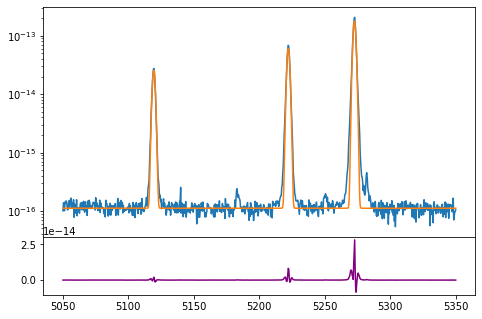

In [119]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_hb0023feige.wavelength, oiii_hb0023feige.flux)

oiiia_wav = 5008.239
oiiib_wav = 4960.295
hb_wav = 4862.721
bkg = 1.1102e-16

hb = gaussian(oiii_hb0023feige.wavelength, 4.5499e-13 * 1/7, hb_wav, z=0.0528, sigma=1)
oiiib = gaussian(oiii_hb0023feige.wavelength, 4.5499e-13 * 1/3, oiiib_wav, z=0.0528, sigma=1)
oiiia = gaussian(oiii_hb0023feige.wavelength, 4.5499e-13, oiiia_wav, z=0.0528, sigma=1)

ax.plot(oiii_hb0023feige.wavelength, bkg + hb + oiiib + oiiia)
ax1.plot(oiii_hb0023feige.wavelength, oiii_hb0023feige.flux - bkg - hb - oiiib - oiiia, color='purple')
ax.set_yscale('log')

In [124]:
params_oiii_hb0023feige = Parameters()

params_oiii_hb0023feige.add('z', value=0.0528)
params_oiii_hb0023feige.add('sigma', value=1, min=0.)
params_oiii_hb0023feige.add('Oiiia_flux', value=4.5499e-13, min=0.)
params_oiii_hb0023feige.add('Oiiib_to_Oiiia', value=1/3, min=0., max=1.)
params_oiii_hb0023feige.add('Hb_to_Oiiia', value=1/7, min=0., max=1.)
params_oiii_hb0023feige.add('bkg', value=1.1102e-16, min=0.)

def residual_oiii_hb0023feige(params_oiii_hb0023feige, x, data, uncertainty):
    oiiia_wav = 5008.239
    oiiib_wav = 4960.295
    hb_wav = 4862.721
    
    z = params_oiii_hb0023feige['z']
    sigma = params_oiii_hb0023feige['sigma']
    oiiia_flux = params_oiii_hb0023feige['Oiiia_flux']
    oiiib_flux = oiiia_flux * params_oiii_hb0023feige['Oiiib_to_Oiiia']
    hb_flux = oiiia_flux * params_oiii_hb0023feige['Hb_to_Oiiia']
    
    bkg_oiii_hb = params_oiii_hb0023feige['bkg']
    
    x = oiii_hb0023feige.wavelength
    model_oiii_hb = gaussian(x, oiiia_flux, oiiia_wav, z, sigma) + gaussian(x, oiiib_flux, oiiib_wav, z, sigma)  + gaussian(x, hb_flux, hb_wav, z, sigma)
    
    return (model_oiii_hb + bkg_oiii_hb - oiii_hb0023feige.flux) / oiii_hb0023feige.noise

In [125]:
out_oiii_hb0023feige = minimize(residual_oiii_hb0023feige, params_oiii_hb0023feige, args=(1, 1, 1),
                      method='emcee', burn=1000, steps=2500, thin=10)

100%|███████████████████████████████████████| 2500/2500 [00:47<00:00, 52.27it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 23.10859756  40.38869095  68.32805211  54.4073329   88.19838788
 152.76683252]


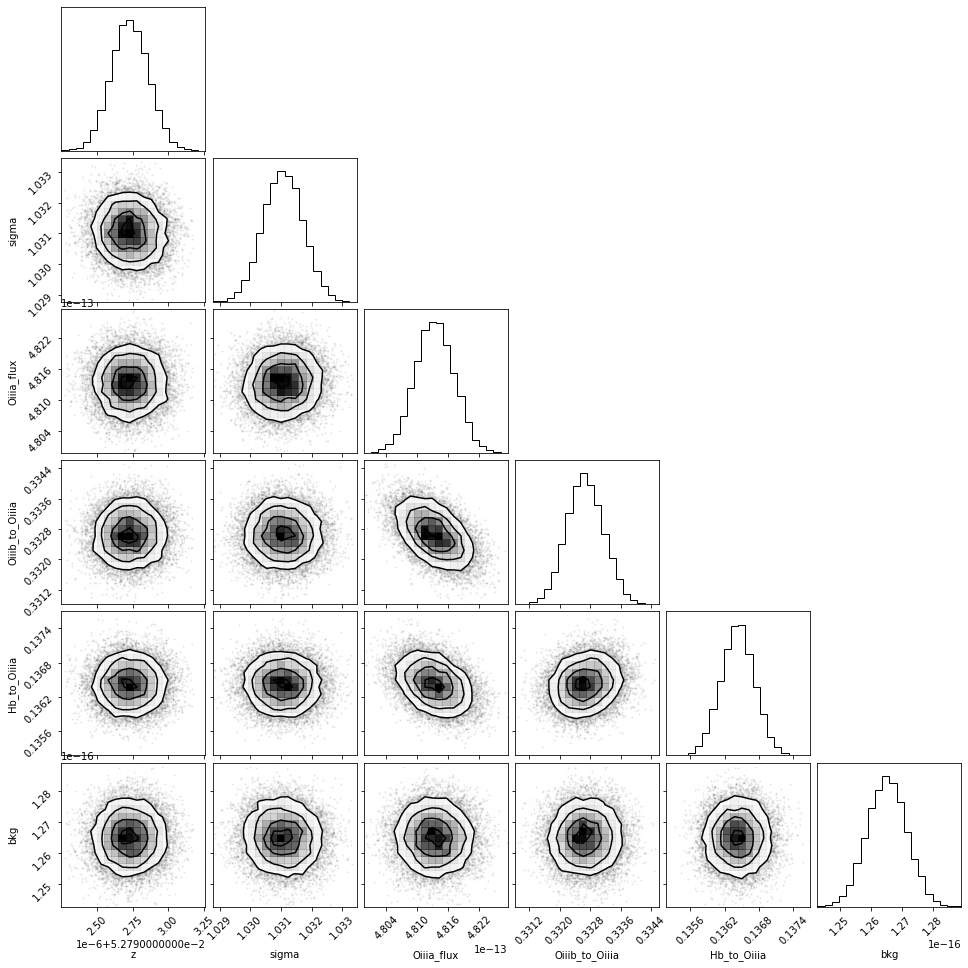

In [126]:
corner.corner(out_oiii_hb0023feige.flatchain, labels=out_oiii_hb0023feige.var_names);

In [127]:
out_oiii_hb0023feige

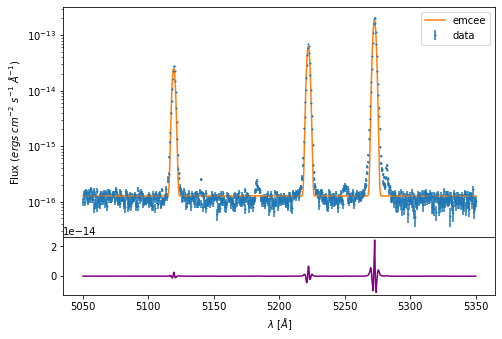

In [128]:
oiiia_flux0023feige = out_oiii_hb0023feige.flatchain.Oiiia_flux.mean()
oiiia_std0023feige = out_oiii_hb0023feige.flatchain.Oiiia_flux.std()

oiiib_flux0023feige = (oiiia_flux0023feige * out_oiii_hb0023feige.flatchain.Oiiib_to_Oiiia).mean()
oiiib_std0023feige = (oiiia_flux0023feige * out_oiii_hb0023feige.flatchain.Oiiib_to_Oiiia).std()

hb_flux0023feige = (oiiia_flux0023feige * out_oiii_hb0023feige.flatchain.Hb_to_Oiiia).mean()
hb_std0023feige = (oiiia_flux0023feige * out_oiii_hb0023feige.flatchain.Hb_to_Oiiia).std()

bkg_oiii_hb0023feige = out_oiii_hb0023feige.flatchain.bkg.mean()
z_oiii_hb0023feige = out_oiii_hb0023feige.flatchain.z.mean()
sigma_oiii_hb0023feige = out_oiii_hb0023feige.flatchain.sigma.mean()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.errorbar(oiii_hb0023feige.wavelength, oiii_hb0023feige.flux, oiii_hb0023feige.noise, ls='', marker='.', markersize=2, label='data')

oiiia0023feige = gaussian(oiii_hb0023feige.wavelength, oiiia_flux0023feige, oiiia_wav, z_oiii_hb0023feige, sigma_oiii_hb0023feige)
oiiib0023feige = gaussian(oiii_hb0023feige.wavelength, oiiib_flux0023feige, oiiib_wav, z_oiii_hb0023feige, sigma_oiii_hb0023feige)
hb0023feige = gaussian(oiii_hb0023feige.wavelength, hb_flux0023feige, hb_wav, z_oiii_hb0023feige, sigma_oiii_hb0023feige)

ax.plot(oiii_hb0023feige.wavelength, bkg_oiii_hb0023feige + hb0023feige + oiiib0023feige + oiiia0023feige, label='emcee')
ax1.plot(oiii_hb0023feige.wavelength, oiii_hb0023feige.flux - bkg_oiii_hb0023feige - hb0023feige - oiiib0023feige - oiiia0023feige, color='purple')
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)')
ax1.set_xlabel(r'$\lambda$ [$\AA$]')
ax.set_yscale('log')
ax.legend()

# J0136

In [132]:
# [NII]6548 + Ha + [NII]6584
select = (J0136_feige.wavelength(9) > 6850) * (J0136_feige.wavelength(9) < 7050)
ha_nii0136feige = SpecPiece('ha+nii', J0136_feige.wavelength(9)[select], 
                   J0136_feige.flux(9)[select], J0136_feige.noise(9)[select])

# Hb + [OIII]4959 + [OIII]5007
select = (J0136_feige.wavelength(12) > 5100) * (J0136_feige.wavelength(12) < 5400)
oiii_hb0136feige = SpecPiece('oiii+hb', J0136_feige.wavelength(12)[select], 
                    J0136_feige.flux(12)[select], J0136_feige.noise(12)[select])

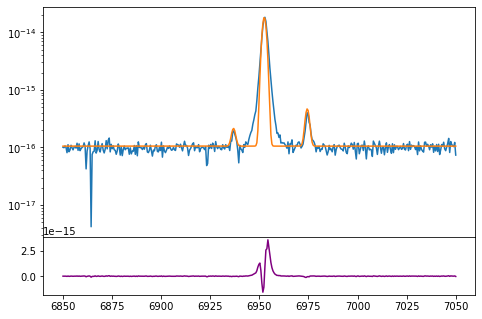

In [144]:
# Search for good initial guess
%matplotlib inline
fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(ha_nii0136feige.wavelength, ha_nii0136feige.flux)

ha_wav = 6564.614
niib_wav = 6549.86
niia_wav = 6585.27
bkg = 1.054839e-16

ha = gaussian(ha_nii0136feige.wavelength, 4.557298e-14, ha_wav, z=0.0591, sigma=1)
niib = gaussian(ha_nii0136feige.wavelength, 4.557298e-14 * 0.006, niib_wav, z=0.0591, sigma=1.)
niia = gaussian(ha_nii0136feige.wavelength, 4.557298e-14 * 0.02, niia_wav, z=0.0591, sigma=1.)

ax.plot(ha_nii0136feige.wavelength, bkg + niib + ha + niia)
ax1.plot(ha_nii0136feige.wavelength, ha_nii0136feige.flux - bkg - niib - ha - niia, color='purple')
ax.set_yscale('log')

In [145]:
params_ha_nii0136feige = Parameters()

params_ha_nii0136feige.add('z', value=0.0595)
params_ha_nii0136feige.add('sigma', value=1., min=0.)
params_ha_nii0136feige.add('Ha_flux', value=4.557298e-14, min=0.)
params_ha_nii0136feige.add('Niib_to_Ha', value=0.006, min=0., max=1.)
params_ha_nii0136feige.add('Niia_to_Ha', value=0.02, min=0., max=1.)
params_ha_nii0136feige.add('bkg', value=1.054839e-16, min=0.)


def residual_ha_nii0136feige(params_ha_nii0136feige, x, data, uncertainty):
    ha_wav = 6564.614
    niib_wav = 6549.86
    niia_wav = 6585.27
    
    z = params_ha_nii0136feige['z']
    sigma = params_ha_nii0136feige['sigma']
    ha_flux = params_ha_nii0136feige['Ha_flux']
    niia_flux = ha_flux * params_ha_nii0136feige['Niia_to_Ha']
    niib_flux = ha_flux * params_ha_nii0136feige['Niib_to_Ha']
    bkg = params_ha_nii0136feige['bkg']
    
    x = ha_nii0136feige.wavelength
    model = gaussian(x, niib_flux, niib_wav, z, sigma) + gaussian(x, ha_flux, ha_wav, z, sigma) + gaussian(x, niia_flux, niia_wav, z, sigma)
    
    return (model + bkg - ha_nii0136feige.flux) / ha_nii0136feige.noise

In [146]:
out_ha_nii0136feige = minimize(residual_ha_nii0136feige, params_ha_nii0136feige, args=(1, 1, 1),
                      method='emcee', burn=1000, steps=2500, thin=10)

100%|███████████████████████████████████████| 2500/2500 [00:42<00:00, 59.23it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 5 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 27.85575797  97.05649182  62.08045132  96.01671641 110.45343619
  61.88665265]


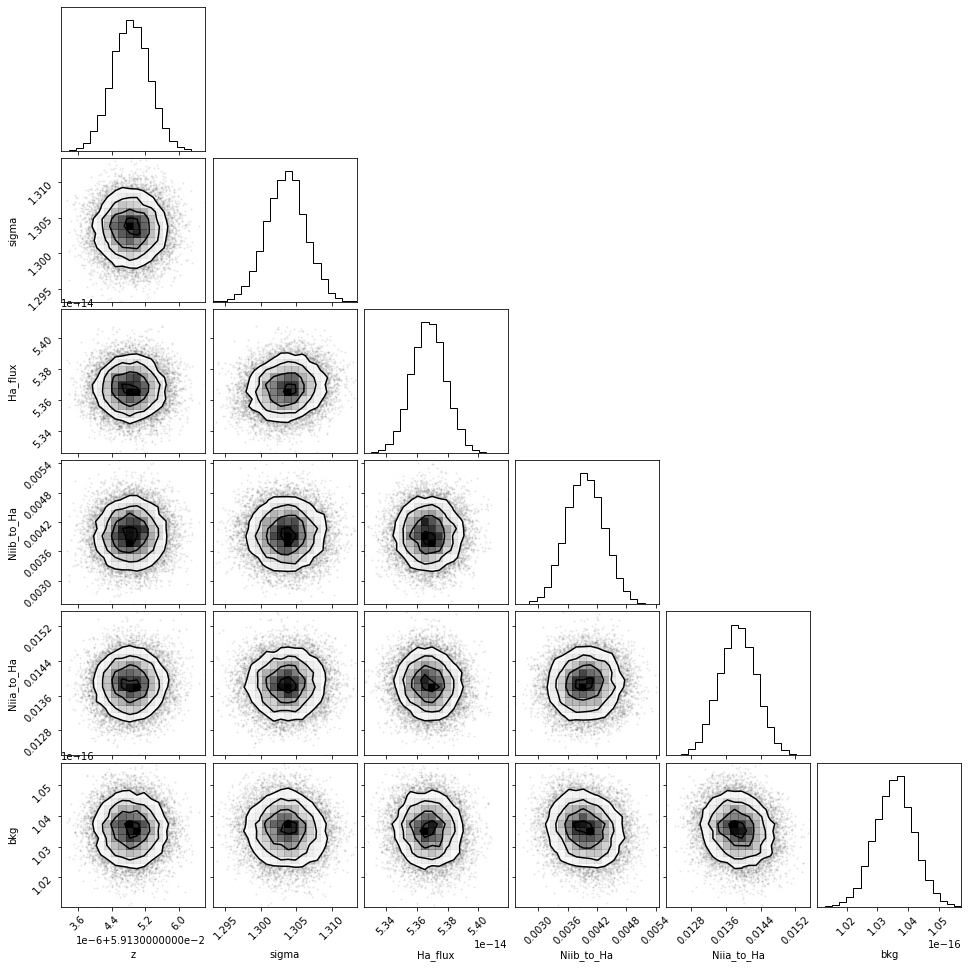

In [147]:
corner.corner(out_ha_nii0136feige.flatchain, labels=out_ha_nii0136feige.var_names);

In [148]:
out_ha_nii0136feige

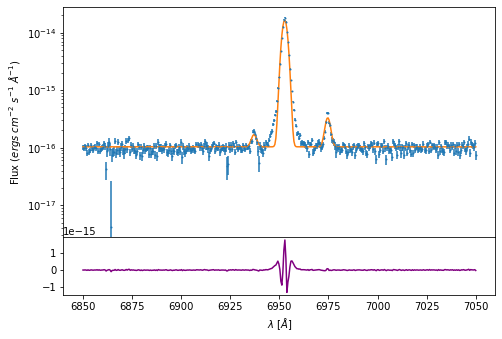

In [149]:
ha_flux0136feige = out_ha_nii0136feige.flatchain.Ha_flux.mean()
ha_std0136feige = out_ha_nii0136feige.flatchain.Ha_flux.std()

niia_flux0136feige = (ha_flux0136feige * out_ha_nii0136feige.flatchain.Niia_to_Ha).mean()
niia_std0136feige = (ha_flux0136feige * out_ha_nii0136feige.flatchain.Niia_to_Ha).std()

niib_flux0136feige = (ha_flux0136feige * out_ha_nii0136feige.flatchain.Niib_to_Ha).mean()
niib_std0136feige = (ha_flux0136feige * out_ha_nii0136feige.flatchain.Niib_to_Ha).std()

bkg_na_nii0136feige = out_ha_nii0136feige.flatchain.bkg.mean()
z_ha_nii0136feige = out_ha_nii0136feige.flatchain.z.mean()
sigma_ha_nii0136feige = out_ha_nii0136feige.flatchain.sigma.mean()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.errorbar(ha_nii0136feige.wavelength, ha_nii0136feige.flux, ha_nii0136feige.noise, ls='', marker='.', markersize=2, label='data')

ha0136feige = gaussian(ha_nii0136feige.wavelength, ha_flux0136feige, ha_wav, z_ha_nii0136feige, sigma_ha_nii0136feige)
niia0136feige = gaussian(ha_nii0136feige.wavelength, niia_flux0136feige, niia_wav, z_ha_nii0136feige, sigma_ha_nii0136feige)
niib0136feige = gaussian(ha_nii0136feige.wavelength, niib_flux0136feige, niib_wav, z_ha_nii0136feige, sigma_ha_nii0136feige)

ax.plot(ha_nii0136feige.wavelength, bkg_na_nii0136feige + niia0136feige + ha0136feige + niib0136feige)
ax1.plot(ha_nii0136feige.wavelength, ha_nii0136feige.flux - bkg_na_nii0136feige - niia0136feige - ha0136feige - niib0136feige, color='purple')
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)')
ax1.set_xlabel(r'$\lambda$ [$\AA$]')
ax.set_yscale('log')

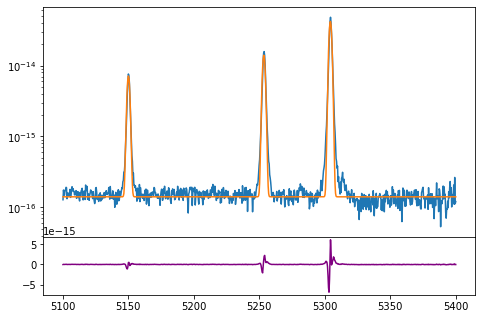

In [163]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_hb0136feige.wavelength, oiii_hb0136feige.flux)

oiiia_wav = 5008.239
oiiib_wav = 4960.295
hb_wav = 4862.721
bkg = 1.4102e-16

hb = gaussian(oiii_hb0136feige.wavelength, 1.0499e-13 * 1/6, hb_wav, z=0.0591, sigma=1)
oiiib = gaussian(oiii_hb0136feige.wavelength, 1.0499e-13 * 1/3, oiiib_wav, z=0.0591, sigma=1)
oiiia = gaussian(oiii_hb0136feige.wavelength, 1.0499e-13, oiiia_wav, z=0.0591, sigma=1)

ax.plot(oiii_hb0136feige.wavelength, bkg + hb + oiiib + oiiia)
ax1.plot(oiii_hb0136feige.wavelength, oiii_hb0136feige.flux - bkg - hb - oiiib - oiiia, color='purple')
ax.set_yscale('log')

In [164]:
params_oiii_hb0136feige = Parameters()

params_oiii_hb0136feige.add('z', value=0.0591)
params_oiii_hb0136feige.add('sigma', value=1, min=0.)
params_oiii_hb0136feige.add('Oiiia_flux', value=1.0499e-13, min=0.)
params_oiii_hb0136feige.add('Oiiib_to_Oiiia', value=1/3, min=0., max=1.)
params_oiii_hb0136feige.add('Hb_to_Oiiia', value=1/6, min=0., max=1.)
params_oiii_hb0136feige.add('bkg', value=1.4102e-16, min=0.)

def residual_oiii_hb0136feige(params_oiii_hb0136feige, x, data, uncertainty):
    oiiia_wav = 5008.239
    oiiib_wav = 4960.295
    hb_wav = 4862.721
    
    z = params_oiii_hb0136feige['z']
    sigma = params_oiii_hb0136feige['sigma']
    oiiia_flux = params_oiii_hb0136feige['Oiiia_flux']
    oiiib_flux = oiiia_flux * params_oiii_hb0136feige['Oiiib_to_Oiiia']
    hb_flux = oiiia_flux * params_oiii_hb0136feige['Hb_to_Oiiia']
    
    bkg_oiii_hb = params_oiii_hb0136feige['bkg']
    
    x = oiii_hb0136feige.wavelength
    model_oiii_hb = gaussian(x, oiiia_flux, oiiia_wav, z, sigma) + gaussian(x, oiiib_flux, oiiib_wav, z, sigma)  + gaussian(x, hb_flux, hb_wav, z, sigma)
    
    return (model_oiii_hb + bkg_oiii_hb - oiii_hb0136feige.flux) / oiii_hb0136feige.noise

In [165]:
out_oiii_hb0136feige = minimize(residual_oiii_hb0136feige, params_oiii_hb0136feige, args=(1, 1, 1),
                      method='emcee', burn=1000, steps=2500, thin=10)

100%|███████████████████████████████████████| 2500/2500 [00:48<00:00, 52.03it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 5 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 20.1196491   60.85387974  86.14900864 109.58205871 127.29415151
 103.23967444]


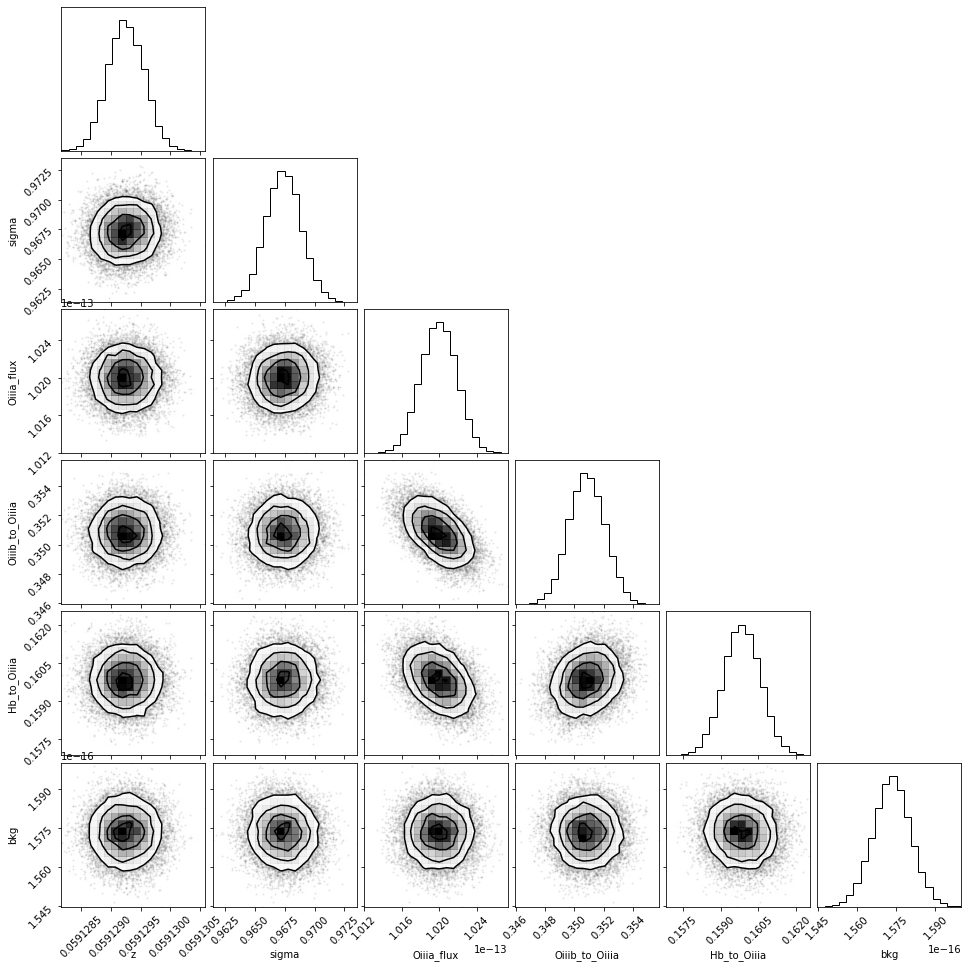

In [166]:
corner.corner(out_oiii_hb0136feige.flatchain, labels=out_oiii_hb0136feige.var_names);

In [168]:
out_oiii_hb0136feige

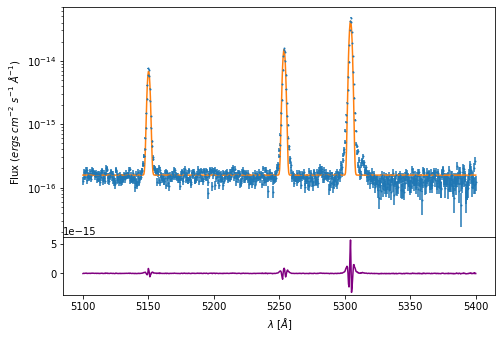

In [172]:
oiiia_flux0136feige = out_oiii_hb0136feige.flatchain.Oiiia_flux.mean()
oiiia_std0136feige = out_oiii_hb0136feige.flatchain.Oiiia_flux.std()

oiiib_flux0136feige = (oiiia_flux0136feige * out_oiii_hb0136feige.flatchain.Oiiib_to_Oiiia).mean()
oiiib_std0136feige = (oiiia_flux0136feige * out_oiii_hb0136feige.flatchain.Oiiib_to_Oiiia).std()

hb_flux0136feige = (oiiia_flux0136feige * out_oiii_hb0136feige.flatchain.Hb_to_Oiiia).mean()
hb_std0136feige = (oiiia_flux0136feige * out_oiii_hb0136feige.flatchain.Hb_to_Oiiia).std()

bkg_oiii_hb0136feige = out_oiii_hb0136feige.flatchain.bkg.mean()
z_oiii_hb0136feige = out_oiii_hb0136feige.flatchain.z.mean()
sigma_oiii_hb0136feige = out_oiii_hb0136feige.flatchain.sigma.mean()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.errorbar(oiii_hb0136feige.wavelength, oiii_hb0136feige.flux, oiii_hb0136feige.noise, ls='', marker='.', markersize=2, label='data')

oiiia0136feige = gaussian(oiii_hb0136feige.wavelength, oiiia_flux0136feige, oiiia_wav, z_oiii_hb0136feige, sigma_oiii_hb0136feige)
oiiib0136feige = gaussian(oiii_hb0136feige.wavelength, oiiib_flux0136feige, oiiib_wav, z_oiii_hb0136feige, sigma_oiii_hb0136feige)
hb0136feige = gaussian(oiii_hb0136feige.wavelength, hb_flux0136feige, hb_wav, z_oiii_hb0136feige, sigma_oiii_hb0136feige)

ax.plot(oiii_hb0136feige.wavelength, bkg_oiii_hb0136feige + hb0136feige + oiiib0136feige + oiiia0136feige, label='emcee')
ax1.plot(oiii_hb0136feige.wavelength, oiii_hb0136feige.flux - bkg_oiii_hb0136feige - hb0136feige - oiiib0136feige - oiiia0136feige, color='purple')
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)')
ax1.set_xlabel(r'$\lambda$ [$\AA$]')
ax.set_yscale('log')

# Line ratios compared to SDSS

In [169]:
from uncertainties import ufloat
import uncertainties.umath as uum

HA_int_sdss = ufloat(galSpecLine_data['h_alpha_flux'][mask_J0023], 
                     galSpecLine_data['h_alpha_flux_err'][mask_J0023])/1000

NII6583_int_sdss = ufloat(galSpecLine_data['nii_6584_flux'][mask_J0023], 
                     galSpecLine_data['nii_6584_flux_err'][mask_J0023])/1000

OIII5006_int_sdss = ufloat(galSpecLine_data['oiii_5007_flux'][mask_J0023], 
                     galSpecLine_data['oiii_5007_flux_err'][mask_J0023])/1000

HB_int_sdss = ufloat(galSpecLine_data['h_beta_flux'][mask_J0023], 
                     galSpecLine_data['h_beta_flux_err'][mask_J0023])/1000

rHA_NII_sdss = NII6583_int_sdss / HA_int_sdss
rha_nii_ltt = ufloat(niia_flux0023feige, niia_std0023feige) / ufloat(ha_flux0023feige, ha_std0023feige)

rOIII_HB_sdss = OIII5006_int_sdss / HB_int_sdss
roiii_hb_ltt = ufloat(oiiia_flux0023feige, oiiia_std0023feige) / ufloat(hb_flux0023feige, hb_std0023feige)

print('J0950 H_alpha/NII6583')
print('Feige110: {:.3f} +/- {:.4f}'.format(rha_nii_ltt.nominal_value, rha_nii_ltt.std_dev))
print('SDSS:    {:.3f} +/- {:.3f}'.format(rHA_NII_sdss.nominal_value, HA_int_sdss.std_dev))
print('----------------------')
print('J0950 OIII/HB')
print('Feige110: {:.3f} +/- {:.3f}'.format(roiii_hb_ltt.nominal_value, roiii_hb_ltt.std_dev))
print('SDSS:    {:.3f} +/- {:.3f}'.format(rOIII_HB_sdss.nominal_value, rOIII_HB_sdss.std_dev))

J0950 H_alpha/NII6583
Feige110: 0.018 +/- 0.0002
SDSS:    0.023 +/- 0.024
----------------------
J0950 OIII/HB
Feige110: 7.330 +/- 0.017
SDSS:    6.224 +/- 0.063


In [173]:
HA_int_sdss = ufloat(galSpecLine_data['h_alpha_flux'][mask_J0136], 
                     galSpecLine_data['h_alpha_flux_err'][mask_J0136])/1000

NII6583_int_sdss = ufloat(galSpecLine_data['nii_6584_flux'][mask_J0136], 
                     galSpecLine_data['nii_6584_flux_err'][mask_J0136])/1000

OIII5006_int_sdss = ufloat(galSpecLine_data['oiii_5007_flux'][mask_J0136], 
                     galSpecLine_data['oiii_5007_flux_err'][mask_J0136])/1000

HB_int_sdss = ufloat(galSpecLine_data['h_beta_flux'][mask_J0136], 
                     galSpecLine_data['h_beta_flux_err'][mask_J0136])/1000

rHA_NII_sdss = NII6583_int_sdss / HA_int_sdss
rha_nii_ltt = ufloat(niia_flux0136feige, niia_std0136feige) / ufloat(ha_flux0136feige, ha_std0136feige)

rOIII_HB_sdss = OIII5006_int_sdss / HB_int_sdss
roiii_hb_ltt = ufloat(oiiia_flux0136feige, oiiia_std0136feige) / ufloat(hb_flux0136feige, hb_std0136feige)

print('J0136 H_alpha/NII6583')
print('Feige110: {:.3f} +/- {:.4f}'.format(rha_nii_ltt.nominal_value, rha_nii_ltt.std_dev))
print('SDSS:    {:.3f} +/- {:.3f}'.format(rHA_NII_sdss.nominal_value, HA_int_sdss.std_dev))
print('----------------------')
print('J0136 OIII/HB')
print('Feige110: {:.3f} +/- {:.3f}'.format(roiii_hb_ltt.nominal_value, roiii_hb_ltt.std_dev))
print('SDSS:    {:.3f} +/- {:.3f}'.format(rOIII_HB_sdss.nominal_value, rOIII_HB_sdss.std_dev))

J0136 H_alpha/NII6583
Feige110: 0.014 +/- 0.0004
SDSS:    0.016 +/- 0.007
----------------------
J0136 OIII/HB
Feige110: 6.256 +/- 0.031
SDSS:    7.212 +/- 0.098
